In [2]:
!pip install -q xgboost shap lime scikit-learn matplotlib seaborn pandas numpy plotly

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 23.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import (mean_squared_error, r2_score, mean_absolute_error,
                             mean_absolute_percentage_error, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.inspection import permutation_importance

import xgboost as xgb
from xgboost import plot_importance

import shap
import lime
import lime.lime_tabular

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_palette("husl")

In [18]:
import csv

aqi_df = pd.read_csv(
    '/content/delhi_ncr_aqi_dataset.csv',
    quoting=csv.QUOTE_NONE,
    on_bad_lines='skip',
    encoding='utf-8',
    encoding_errors='replace',
    dtype=str
)

meteo_df = pd.read_csv(
    '/content/open-meteo-28.58N77.19E214m.csv',
    skiprows=3,
    dtype=str
)

for col in aqi_df.columns:
    aqi_df[col] = aqi_df[col].astype(str).str.replace('"', '', regex=False).str.strip()

for col in meteo_df.columns:
    meteo_df[col] = meteo_df[col].astype(str).str.replace('"', '', regex=False).str.strip()

meteo_df.rename(columns={
    'time': 'datetime',
    'temperature_2m (°C)': 'met_temp',
    'relative_humidity_2m (%)': 'met_humidity',
    'wind_speed_10m (km/h)': 'met_wind_speed',
    'wind_direction_10m (°)': 'met_wind_dir',
    'precipitation (mm)': 'met_precip',
    'surface_pressure (hPa)': 'met_pressure',
    'cloud_cover (%)': 'met_cloud_cover',
    'dew_point_2m (°C)': 'met_dew_point'
}, inplace=True)

aqi_numeric = ['pm25','pm10','no2','so2','co','o3','temperature','humidity',
               'wind_speed','visibility','aqi','latitude','longitude',
               'year','month','day','hour','is_weekend']
for col in aqi_numeric:
    if col in aqi_df.columns:
        aqi_df[col] = pd.to_numeric(aqi_df[col], errors='coerce')

meteo_numeric = ['met_temp','met_humidity','met_wind_speed','met_wind_dir',
                 'met_pressure','met_precip','met_cloud_cover','met_dew_point']
for col in meteo_numeric:
    if col in meteo_df.columns:
        meteo_df[col] = pd.to_numeric(meteo_df[col], errors='coerce')

aqi_df['datetime'] = pd.to_datetime(aqi_df['datetime'], format='mixed', errors='coerce')
aqi_df['date']     = pd.to_datetime(aqi_df['date'],     format='mixed', errors='coerce')
meteo_df['datetime'] = pd.to_datetime(meteo_df['datetime'], format='mixed', errors='coerce')

aqi_df.dropna(subset=['datetime'], inplace=True)
meteo_df.dropna(subset=['datetime'], inplace=True)

print(f"AQI shape:   {aqi_df.shape}")
print(f"Meteo shape: {meteo_df.shape}")
print(f"AQI dtypes:\n{aqi_df[aqi_numeric].dtypes}")
print(f"\nAQI date range: {aqi_df['datetime'].min()} → {aqi_df['datetime'].max()}")
print(f"Meteo date range: {meteo_df['datetime'].min()} → {meteo_df['datetime'].max()}")

AQI shape:   (201664, 25)
Meteo shape: (52608, 9)
AQI dtypes:
pm25           float64
pm10           float64
no2            float64
so2            float64
co             float64
o3             float64
temperature    float64
humidity       float64
wind_speed     float64
visibility     float64
aqi            float64
latitude       float64
longitude      float64
year             int64
month            int64
day              int64
hour           float64
is_weekend     float64
dtype: object

AQI date range: 2020-01-01 00:00:00 → 2025-12-31 00:00:00
Meteo date range: 2019-01-01 00:00:00 → 2024-12-31 23:00:00


In [19]:
pollutants = ['pm25', 'pm10', 'no2', 'so2', 'co', 'o3']
meteo_vars = ['temperature', 'humidity', 'wind_speed', 'visibility']

print("=== Pollutant Statistics ===")
print(aqi_df[pollutants].describe().round(2))

print("\n=== AQI Category Distribution ===")
cat_counts = aqi_df['aqi_category'].value_counts()
print(cat_counts)
print(f"\nPercentages:\n{(cat_counts / len(aqi_df) * 100).round(2)}")

def detect_outliers_iqr(df, cols):
    report = {}
    for col in cols:
        Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
        n = ((df[col] < lower) | (df[col] > upper)).sum()
        report[col] = {'lower': round(lower,2), 'upper': round(upper,2),
                       'n_outliers': n, 'pct': round(n/len(df)*100, 2)}
    return pd.DataFrame(report).T

print("\n=== IQR Outlier Report ===")
print(detect_outliers_iqr(aqi_df, pollutants + meteo_vars))

=== Pollutant Statistics ===
            pm25       pm10        no2        so2         co         o3
count  201664.00  201664.00  201664.00  201664.00  201664.00  201664.00
mean      246.65     241.83      49.00      11.25      12.56      27.02
std       284.16     326.50      66.58      15.55      14.76      12.02
min        15.00       8.00       4.00       0.30       0.30       6.00
25%        67.90      46.00       9.30       2.94       1.31      18.30
50%       138.55     115.50      23.20       5.09       5.08      25.00
75%       316.20     304.40      62.10      13.41      20.90      32.90
max      1979.70    1979.70     591.80     121.60      84.00      84.00

=== AQI Category Distribution ===
aqi_category
nan             78912
Severe          37138
Moderate        27435
Satisfactory    19601
Very Poor       18026
Poor            11781
Good             8771
Name: count, dtype: int64

Percentages:
aqi_category
nan             39.13
Severe          18.42
Moderate        13.60
Sa

In [20]:
def winsorize_column(series, lower_pct=0.01, upper_pct=0.99):
    lower = series.quantile(lower_pct)
    upper = series.quantile(upper_pct)
    return series.clip(lower=lower, upper=upper)

aqi_clean = aqi_df.copy()

for col in pollutants:
    aqi_clean[col] = winsorize_column(aqi_clean[col])

aqi_clean['aqi'] = winsorize_column(aqi_clean['aqi'])
aqi_clean = aqi_clean.dropna(subset=['aqi', 'pm25', 'pm10', 'datetime'])

print(f"Records before: {len(aqi_df):,}")
print(f"Records after:  {len(aqi_clean):,}")
print(f"AQI stats:\n{aqi_clean['aqi'].describe().round(2)}")

Records before: 201,664
Records after:  122,752
AQI stats:
count    122752.00
mean        268.12
std         171.49
min          31.00
25%         105.00
50%         238.00
75%         472.00
max         500.00
Name: aqi, dtype: float64


In [21]:
aqi_clean = aqi_clean.copy()
meteo_df  = meteo_df.copy()

aqi_clean['datetime_hour'] = aqi_clean['datetime'].dt.floor('h')
meteo_df['datetime_hour']  = meteo_df['datetime'].dt.floor('h')

df = pd.merge(
    aqi_clean,
    meteo_df.drop(columns=['datetime']),
    on='datetime_hour',
    how='left'
)

df['met_temp'].fillna(df['temperature'],  inplace=True)
df['met_humidity'].fillna(df['humidity'], inplace=True)
df['met_wind_speed'].fillna(df['wind_speed'], inplace=True)
df['met_precip'].fillna(0, inplace=True)

for col in meteo_numeric:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        df[col].fillna(df[col].median(), inplace=True)

overlap_start = max(aqi_clean['datetime'].min(), meteo_df['datetime'].min())
overlap_end   = min(aqi_clean['datetime'].max(), meteo_df['datetime'].max())

df_overlap = df[(df['datetime'] >= overlap_start) & (df['datetime'] <= overlap_end)].copy()
df_overlap.reset_index(drop=True, inplace=True)

print(f"Merged shape:   {df.shape}")
print(f"Overlap period: {overlap_start.date()} → {overlap_end.date()}")
print(f"Overlap rows:   {len(df_overlap):,}")
print(f"\nMeteo null check:\n{df_overlap[meteo_numeric].isnull().sum()}")

Merged shape:   (122752, 34)
Overlap period: 2020-01-01 → 2024-12-31
Overlap rows:   102,312

Meteo null check:
met_temp           0
met_humidity       0
met_wind_speed     0
met_wind_dir       0
met_pressure       0
met_precip         0
met_cloud_cover    0
met_dew_point      0
dtype: int64


In [22]:
df_feat = df_overlap.copy()
df_feat = df_feat.sort_values(['city', 'datetime']).reset_index(drop=True)

df_feat['hour']  = pd.to_numeric(df_feat['hour'],  errors='coerce').fillna(0).astype(int)
df_feat['month'] = pd.to_numeric(df_feat['month'], errors='coerce').fillna(1).astype(int)

df_feat['hour_sin']  = np.sin(2 * np.pi * df_feat['hour']  / 24)
df_feat['hour_cos']  = np.cos(2 * np.pi * df_feat['hour']  / 24)
df_feat['month_sin'] = np.sin(2 * np.pi * df_feat['month'] / 12)
df_feat['month_cos'] = np.cos(2 * np.pi * df_feat['month'] / 12)

dow_map = {'Monday':0,'Tuesday':1,'Wednesday':2,'Thursday':3,
           'Friday':4,'Saturday':5,'Sunday':6}
if df_feat['day_of_week'].dtype == object:
    dow_numeric = df_feat['day_of_week'].map(dow_map).fillna(0)
else:
    dow_numeric = pd.to_numeric(df_feat['day_of_week'], errors='coerce').fillna(0)

df_feat['dow_sin'] = np.sin(2 * np.pi * dow_numeric / 7)
df_feat['dow_cos'] = np.cos(2 * np.pi * dow_numeric / 7)

poll_targets = ['pm25', 'pm10', 'no2', 'aqi']
lag_steps    = [1, 2, 3, 6, 12, 24]
roll_windows = [3, 6, 24]

grp = df_feat.groupby('city', sort=False)
lag_cols_dict = {}

for poll in poll_targets:
    for lag in lag_steps:
        lag_cols_dict[f'{poll}_lag{lag}h'] = grp[poll].shift(lag)
    for w in roll_windows:
        lag_cols_dict[f'{poll}_roll{w}h'] = grp[poll].transform(
            lambda x: x.rolling(w, min_periods=1).mean())

lag_df  = pd.DataFrame(lag_cols_dict, index=df_feat.index)
df_feat = pd.concat([df_feat, lag_df], axis=1)

df_feat['temp_humidity_interaction'] = df_feat['met_temp'].astype(float) * df_feat['met_humidity'].astype(float)
df_feat['wind_precip_interaction']   = df_feat['met_wind_speed'].astype(float) * (df_feat['met_precip'].astype(float) + 0.001)
df_feat['dew_depression']            = df_feat['met_temp'].astype(float) - df_feat['met_dew_point'].astype(float)
df_feat['pm_ratio']                  = df_feat['pm25'].astype(float) / (df_feat['pm10'].astype(float) + 0.001)
df_feat['nox_approx']                = df_feat['no2'].astype(float) + df_feat['o3'].astype(float)

season_map = {'winter':0,'spring':1,'summer':2,'monsoon':3,'post-monsoon':4}
df_feat['season_code'] = df_feat['season'].map(season_map).fillna(0).astype(int)

le_city    = LabelEncoder()
le_station = LabelEncoder()
le_cat     = LabelEncoder()

df_feat['city_code']    = le_city.fit_transform(df_feat['city'].astype(str))
df_feat['station_code'] = le_station.fit_transform(df_feat['station'].astype(str))
df_feat['aqi_cat_code'] = le_cat.fit_transform(df_feat['aqi_category'].astype(str))
aqi_cat_classes         = le_cat.classes_

lag_feature_cols = [c for c in df_feat.columns if 'lag' in c]
df_feat.dropna(subset=lag_feature_cols, inplace=True)
df_feat = df_feat.sort_values('datetime').reset_index(drop=True)

print(f"Final shape:            {df_feat.shape}")
print(f"Lag/roll features:      {len(lag_cols_dict)}")
print(f"Date range:             {df_feat['datetime'].min().date()} → {df_feat['datetime'].max().date()}")
print(f"AQI category encoding:  {dict(zip(aqi_cat_classes, le_cat.transform(aqi_cat_classes)))}")

Final shape:            (101976, 85)
Lag/roll features:      36
Date range:             2020-01-07 → 2024-12-31
AQI category encoding:  {'Good': np.int64(0), 'Moderate': np.int64(1), 'Poor': np.int64(2), 'Satisfactory': np.int64(3), 'Severe': np.int64(4), 'Very Poor': np.int64(5)}


In [23]:
feature_cols = (
    pollutants +
    ['met_temp','met_humidity','met_wind_speed','met_wind_dir',
     'met_pressure','met_precip','met_cloud_cover','met_dew_point',
     'visibility','hour_sin','hour_cos','month_sin','month_cos',
     'dow_sin','dow_cos','is_weekend','season_code','city_code','station_code',
     'temp_humidity_interaction','wind_precip_interaction',
     'dew_depression','pm_ratio','nox_approx'] +
    [c for c in df_feat.columns if 'lag' in c or 'roll' in c]
)

feature_cols = [c for c in dict.fromkeys(feature_cols) if c in df_feat.columns]

X      = df_feat[feature_cols].copy().apply(pd.to_numeric, errors='coerce')
y_reg  = pd.to_numeric(df_feat['aqi'], errors='coerce')
y_cls  = df_feat['aqi_cat_code'].copy()

X.fillna(X.median(), inplace=True)

valid_mask = y_reg.notna()
X, y_reg, y_cls = X[valid_mask], y_reg[valid_mask], y_cls[valid_mask]

X_temp, X_test, y_reg_temp, y_reg_test, y_cls_temp, y_cls_test = train_test_split(
    X, y_reg, y_cls, test_size=0.15, random_state=42, shuffle=False)

X_train, X_val, y_reg_train, y_reg_val, y_cls_train, y_cls_val = train_test_split(
    X_temp, y_reg_temp, y_cls_temp,
    test_size=0.15/0.85, random_state=42, shuffle=False)

scaler       = StandardScaler()
X_train_sc   = scaler.fit_transform(X_train)
X_val_sc     = scaler.transform(X_val)
X_test_sc    = scaler.transform(X_test)

print(f"Features:    {len(feature_cols)}")
print(f"Train:       {len(X_train):,}  ({len(X_train)/len(X)*100:.1f}%)")
print(f"Validation:  {len(X_val):,}  ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test:        {len(X_test):,}  ({len(X_test)/len(X)*100:.1f}%)")
print(f"AQI range — Train: {y_reg_train.min():.1f}–{y_reg_train.max():.1f} | Test: {y_reg_test.min():.1f}–{y_reg_test.max():.1f}")

Features:    66
Train:       71,382  (70.0%)
Validation:  15,297  (15.0%)
Test:        15,297  (15.0%)
AQI range — Train: 31.0–500.0 | Test: 31.0–500.0


In [24]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42,
    oob_score=True
)

rf_model.fit(X_train, y_reg_train)

y_pred_rf_val = rf_model.predict(X_val)
y_pred_rf_test = rf_model.predict(X_test)

def evaluate_regression(y_true, y_pred, model_name, split='Test'):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    print(f"\n{'='*40}")
    print(f"{model_name} — {split} Set")
    print(f"{'='*40}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MAE  : {mae:.4f}")
    print(f"  R²   : {r2:.4f}")
    print(f"  MAPE : {mape:.2f}%")
    return {'Model': model_name, 'Split': split, 'RMSE': rmse, 'MAE': mae, 'R2': r2, 'MAPE': mape}

rf_val_metrics = evaluate_regression(y_reg_val, y_pred_rf_val, 'Random Forest', 'Validation')
rf_test_metrics = evaluate_regression(y_reg_test, y_pred_rf_test, 'Random Forest', 'Test')
print(f"\n  OOB Score: {rf_model.oob_score_:.4f}")


Random Forest — Validation Set
  RMSE : 3.6114
  MAE  : 2.1853
  R²   : 0.9996
  MAPE : 1.18%

Random Forest — Test Set
  RMSE : 3.1611
  MAE  : 1.9475
  R²   : 0.9997
  MAPE : 1.50%

  OOB Score: 0.9995



XGBoost — Validation Set
  RMSE : 0.8424
  MAE  : 0.5209
  R²   : 1.0000
  MAPE : 0.30%

XGBoost — Test Set
  RMSE : 0.6661
  MAE  : 0.4233
  R²   : 1.0000
  MAPE : 0.34%


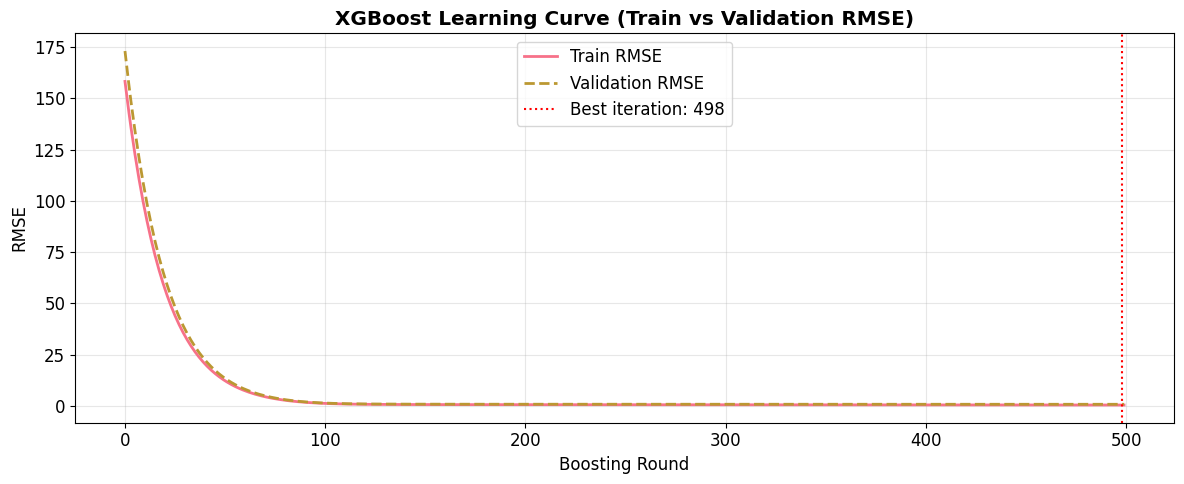


Best iteration: 498


In [25]:
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    n_jobs=-1,
    random_state=42,
    eval_metric='rmse',
    early_stopping_rounds=30,
    verbosity=0
)

eval_set = [(X_train, y_reg_train), (X_val, y_reg_val)]
xgb_model.fit(X_train, y_reg_train,
              eval_set=eval_set,
              verbose=False)

y_pred_xgb_val = xgb_model.predict(X_val)
y_pred_xgb_test = xgb_model.predict(X_test)

xgb_val_metrics = evaluate_regression(y_reg_val, y_pred_xgb_val, 'XGBoost', 'Validation')
xgb_test_metrics = evaluate_regression(y_reg_test, y_pred_xgb_test, 'XGBoost', 'Test')

results = xgb_model.evals_result()
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(results['validation_0']['rmse'], label='Train RMSE', linewidth=2)
ax.plot(results['validation_1']['rmse'], label='Validation RMSE', linewidth=2, linestyle='--')
ax.axvline(xgb_model.best_iteration, color='red', linestyle=':', label=f'Best iteration: {xgb_model.best_iteration}')
ax.set_xlabel('Boosting Round')
ax.set_ylabel('RMSE')
ax.set_title('XGBoost Learning Curve (Train vs Validation RMSE)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()
print(f"\nBest iteration: {xgb_model.best_iteration}")


=== Full Model Comparison Table ===
        Model      Split     RMSE      MAE       R2     MAPE
Random Forest Validation 3.611352 2.185272 0.999592 1.178628
Random Forest       Test 3.161099 1.947486 0.999681 1.500755
      XGBoost Validation 0.842402 0.520907 0.999978 0.296686
      XGBoost       Test 0.666076 0.423329 0.999986 0.339463


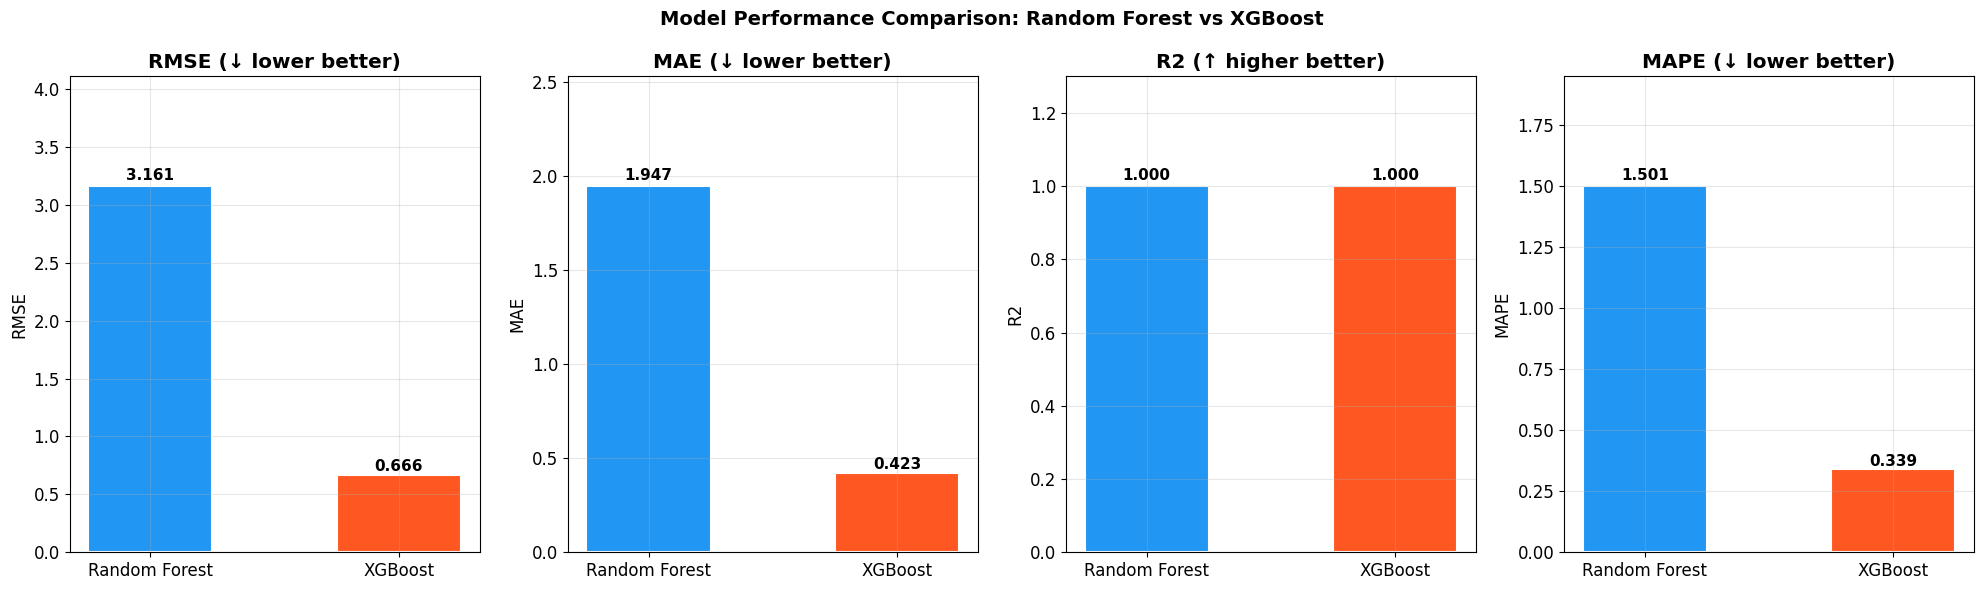

In [26]:
all_metrics = [rf_val_metrics, rf_test_metrics, xgb_val_metrics, xgb_test_metrics]
metrics_df = pd.DataFrame(all_metrics)

print("\n=== Full Model Comparison Table ===")
print(metrics_df.to_string(index=False))

fig, axes = plt.subplots(1, 4, figsize=(20, 6))
fig.suptitle('Model Performance Comparison: Random Forest vs XGBoost', fontsize=14, fontweight='bold')

metric_names = ['RMSE', 'MAE', 'R2', 'MAPE']
better = ['lower', 'lower', 'higher', 'lower']
colors_map = {'Random Forest': '#2196F3', 'XGBoost': '#FF5722'}

for ax, metric, direction in zip(axes, metric_names, better):
    test_data = metrics_df[metrics_df['Split'] == 'Test']
    bars = ax.bar(test_data['Model'], test_data[metric],
                  color=[colors_map[m] for m in test_data['Model']],
                  edgecolor='white', linewidth=1.5, width=0.5)
    for bar, val in zip(bars, test_data[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01 * bar.get_height(),
                f'{val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
    ax.set_title(f'{metric} ({"↓ lower better" if direction=="lower" else "↑ higher better"})',
                 fontweight='bold')
    ax.set_ylabel(metric)
    ax.set_ylim(0, test_data[metric].max() * 1.3)

plt.tight_layout()
plt.show()

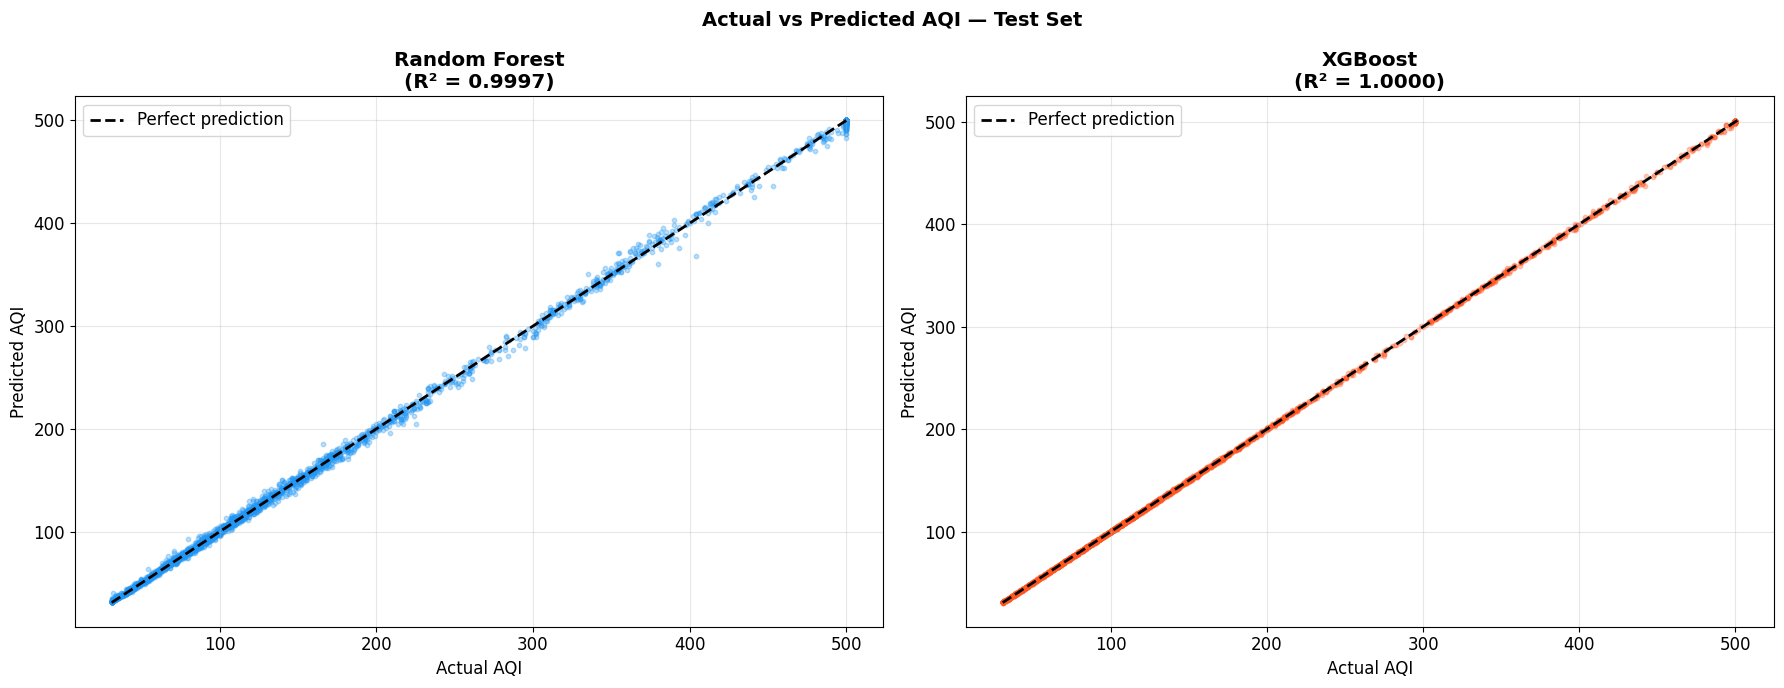

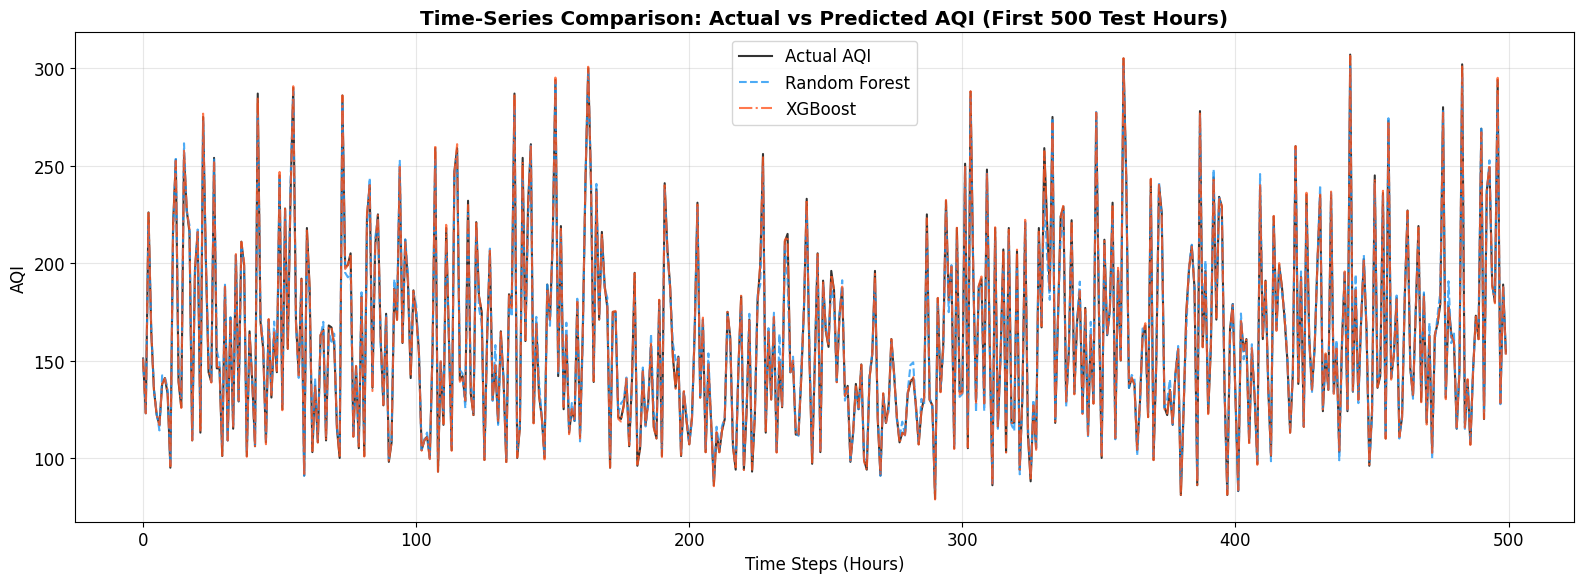

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, (y_pred, name, color) in zip(axes, [
    (y_pred_rf_test, 'Random Forest', '#2196F3'),
    (y_pred_xgb_test, 'XGBoost', '#FF5722')
]):
    sample_idx = np.random.choice(len(y_reg_test), min(3000, len(y_reg_test)), replace=False)
    ax.scatter(y_reg_test.iloc[sample_idx], y_pred[sample_idx],
               alpha=0.3, s=10, color=color)
    min_val = min(y_reg_test.min(), y_pred.min())
    max_val = max(y_reg_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2, label='Perfect prediction')
    r2 = r2_score(y_reg_test, y_pred)
    ax.set_xlabel('Actual AQI')
    ax.set_ylabel('Predicted AQI')
    ax.set_title(f'{name}\n(R² = {r2:.4f})', fontweight='bold')
    ax.legend()

plt.suptitle('Actual vs Predicted AQI — Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

fig2, ax = plt.subplots(figsize=(16, 6))
sample_n = 500
idx_start = 0
ax.plot(range(sample_n), y_reg_test.values[idx_start:idx_start+sample_n],
        label='Actual AQI', linewidth=1.5, color='black', alpha=0.8)
ax.plot(range(sample_n), y_pred_rf_test[idx_start:idx_start+sample_n],
        label='Random Forest', linewidth=1.5, color='#2196F3', alpha=0.8, linestyle='--')
ax.plot(range(sample_n), y_pred_xgb_test[idx_start:idx_start+sample_n],
        label='XGBoost', linewidth=1.5, color='#FF5722', alpha=0.8, linestyle='-.')
ax.set_xlabel('Time Steps (Hours)')
ax.set_ylabel('AQI')
ax.set_title('Time-Series Comparison: Actual vs Predicted AQI (First 500 Test Hours)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


Classification Report — Random Forest
              precision    recall  f1-score   support

        Good       1.00      1.00      1.00      1553
    Moderate       1.00      1.00      1.00      4071
        Poor       1.00      1.00      1.00      1006
Satisfactory       1.00      1.00      1.00      3420
      Severe       1.00      1.00      1.00      4134
   Very Poor       1.00      1.00      1.00      1113

    accuracy                           1.00     15297
   macro avg       1.00      1.00      1.00     15297
weighted avg       1.00      1.00      1.00     15297


Classification Report — XGBoost
              precision    recall  f1-score   support

        Good       0.99      0.98      0.98      1553
    Moderate       0.99      1.00      1.00      4071
        Poor       1.00      0.99      0.99      1006
Satisfactory       0.99      0.99      0.99      3420
      Severe       1.00      1.00      1.00      4134
   Very Poor       0.99      0.99      0.99      1113

    a

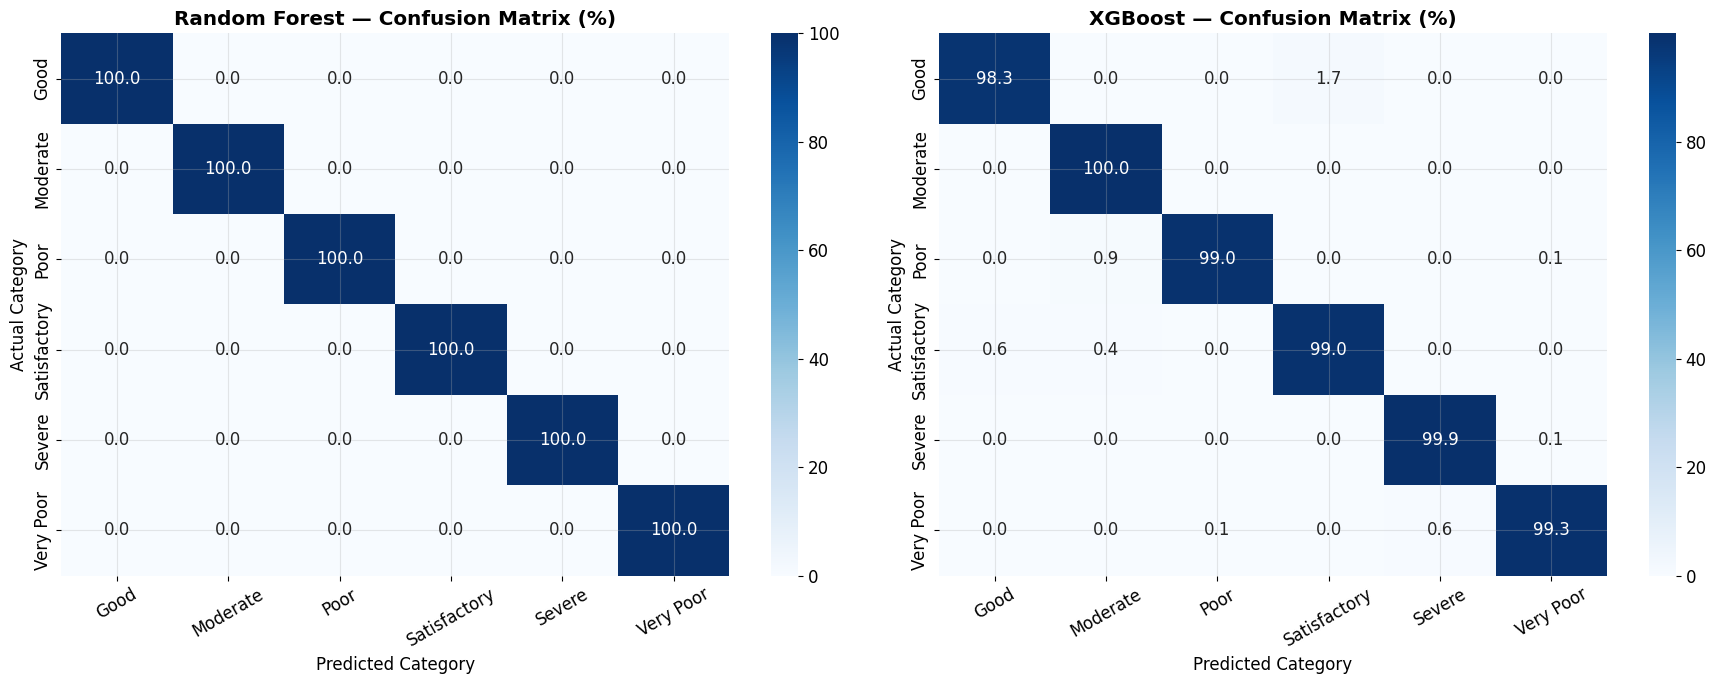

In [28]:
rf_cls = RandomForestClassifier(
    n_estimators=300, max_depth=20, n_jobs=-1, random_state=42, class_weight='balanced')
rf_cls.fit(X_train, y_cls_train)

xgb_cls = xgb.XGBClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=8,
    subsample=0.8, colsample_bytree=0.8, n_jobs=-1, random_state=42,
    use_label_encoder=False, eval_metric='mlogloss', verbosity=0)
xgb_cls.fit(X_train, y_cls_train)

for model, name in [(rf_cls, 'Random Forest'), (xgb_cls, 'XGBoost')]:
    y_pred_cls = model.predict(X_test)
    print(f"\n{'='*45}")
    print(f"Classification Report — {name}")
    print(f"{'='*45}")
    print(classification_report(y_cls_test, y_pred_cls, target_names=aqi_cat_classes))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, (model, name) in zip(axes, [(rf_cls, 'Random Forest'), (xgb_cls, 'XGBoost')]):
    y_pred_cls = model.predict(X_test)
    cm = confusion_matrix(y_cls_test, y_pred_cls)
    cm_pct = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis] * 100
    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues', ax=ax,
                xticklabels=aqi_cat_classes, yticklabels=aqi_cat_classes)
    ax.set_xlabel('Predicted Category')
    ax.set_ylabel('Actual Category')
    ax.set_title(f'{name} — Confusion Matrix (%)', fontweight='bold')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

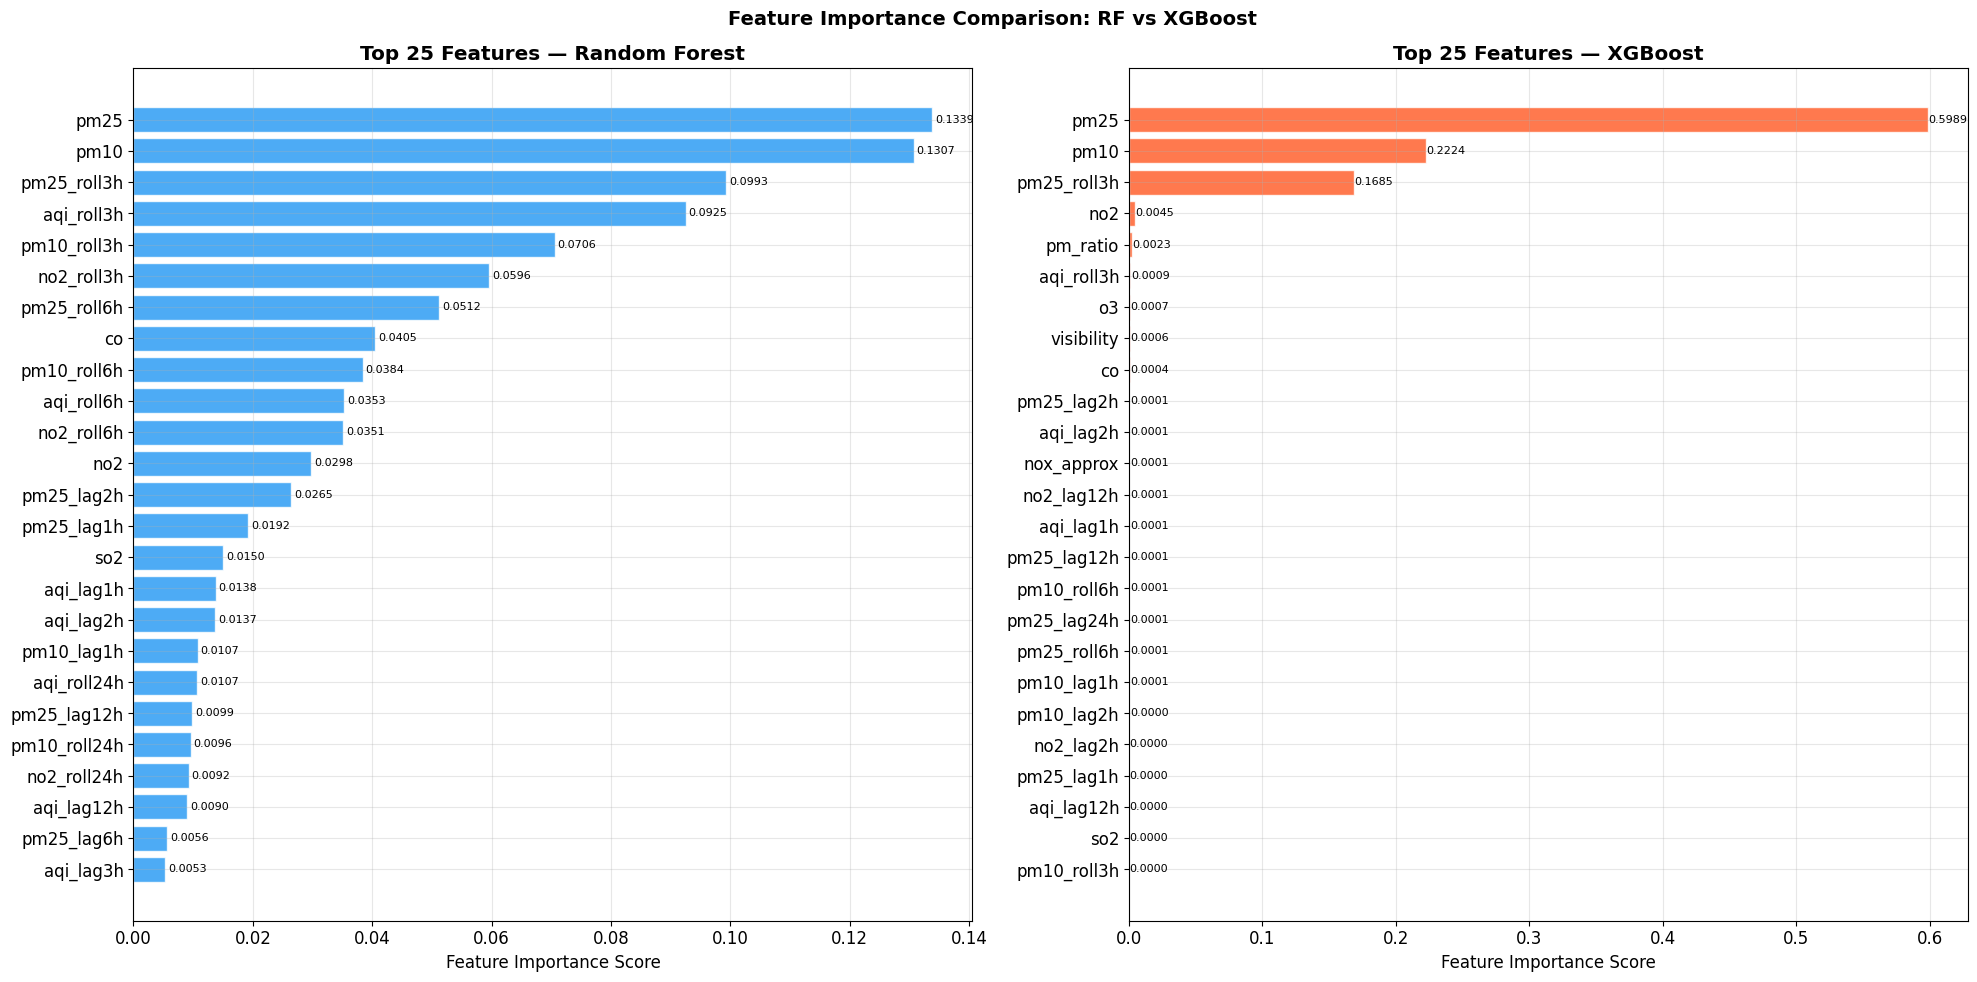


Top 10 features in BOTH models (agreement): {'co', 'pm25', 'aqi_roll3h', 'pm10', 'pm25_roll3h'}
Only in RF top-10: {'pm10_roll3h', 'pm25_roll6h', 'pm10_roll6h', 'no2_roll3h', 'aqi_roll6h'}
Only in XGB top-10: {'no2', 'pm25_lag2h', 'o3', 'pm_ratio', 'visibility'}


In [29]:
rf_importances = pd.Series(rf_model.feature_importances_, index=feature_cols)
xgb_importances = pd.Series(xgb_model.feature_importances_, index=feature_cols)

top_n = 25
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

for ax, (importances, name, color) in zip(axes, [
    (rf_importances, 'Random Forest', '#2196F3'),
    (xgb_importances, 'XGBoost', '#FF5722')
]):
    top = importances.nlargest(top_n).sort_values()
    bars = ax.barh(top.index, top.values, color=color, alpha=0.8, edgecolor='white')
    ax.set_xlabel('Feature Importance Score')
    ax.set_title(f'Top {top_n} Features — {name}', fontweight='bold')
    for bar in bars:
        ax.text(bar.get_width() + 0.0005, bar.get_y() + bar.get_height()/2,
                f'{bar.get_width():.4f}', va='center', fontsize=8)

plt.suptitle('Feature Importance Comparison: RF vs XGBoost', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

rf_top10 = set(rf_importances.nlargest(10).index)
xgb_top10 = set(xgb_importances.nlargest(10).index)
print(f"\nTop 10 features in BOTH models (agreement): {rf_top10 & xgb_top10}")
print(f"Only in RF top-10: {rf_top10 - xgb_top10}")
print(f"Only in XGB top-10: {xgb_top10 - rf_top10}")

SHAP values shape: (2000, 66)
Computing global SHAP plots...


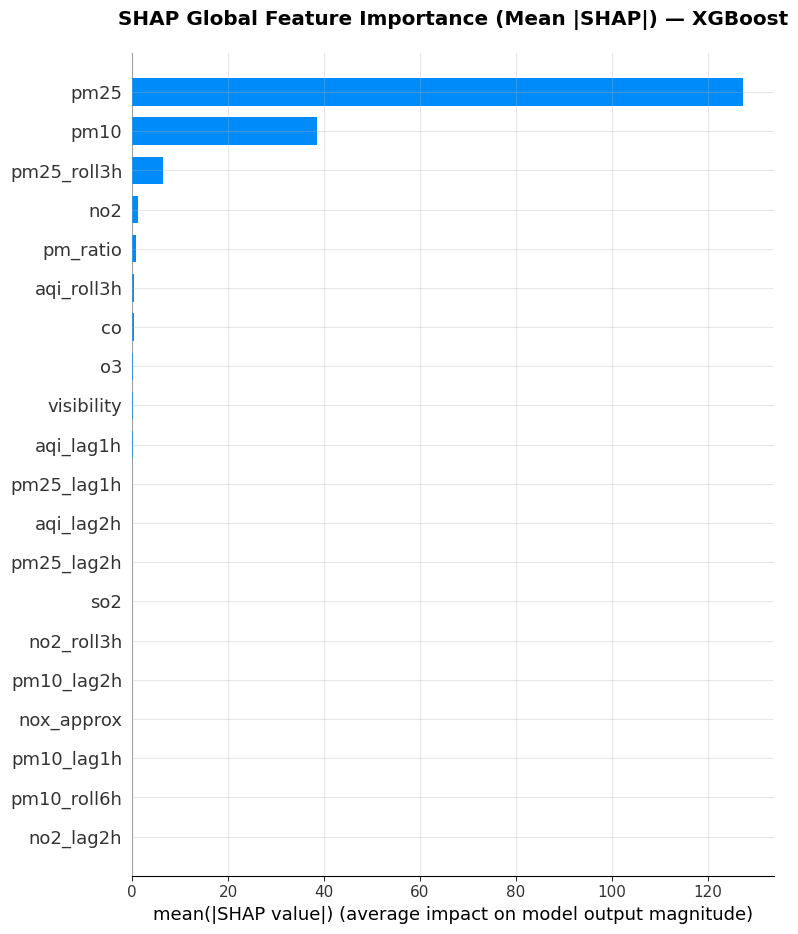

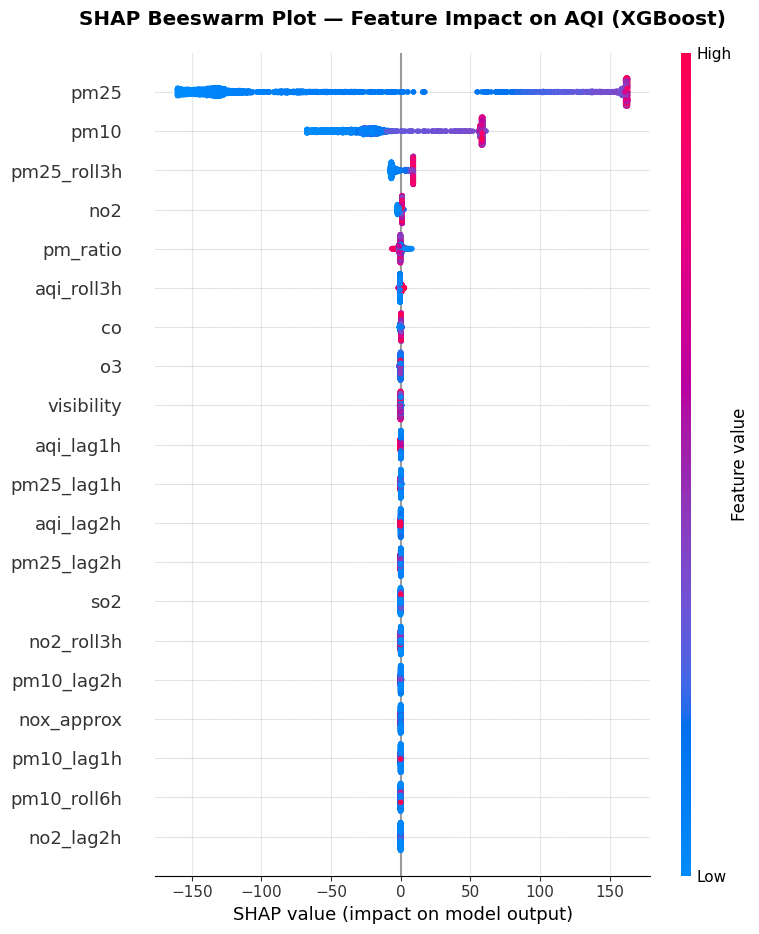

In [30]:
shap_sample = X_test.sample(min(2000, len(X_test)), random_state=42)

explainer_xgb = shap.TreeExplainer(xgb_model)
shap_values_xgb = explainer_xgb.shap_values(shap_sample)

print(f"SHAP values shape: {shap_values_xgb.shape}")
print("Computing global SHAP plots...")

plt.figure(figsize=(14, 10))
shap.summary_plot(shap_values_xgb, shap_sample, plot_type='bar',
                  feature_names=feature_cols, max_display=20, show=False)
plt.title('SHAP Global Feature Importance (Mean |SHAP|) — XGBoost', fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 12))
shap.summary_plot(shap_values_xgb, shap_sample,
                  feature_names=feature_cols, max_display=20, show=False)
plt.title('SHAP Beeswarm Plot — Feature Impact on AQI (XGBoost)', fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

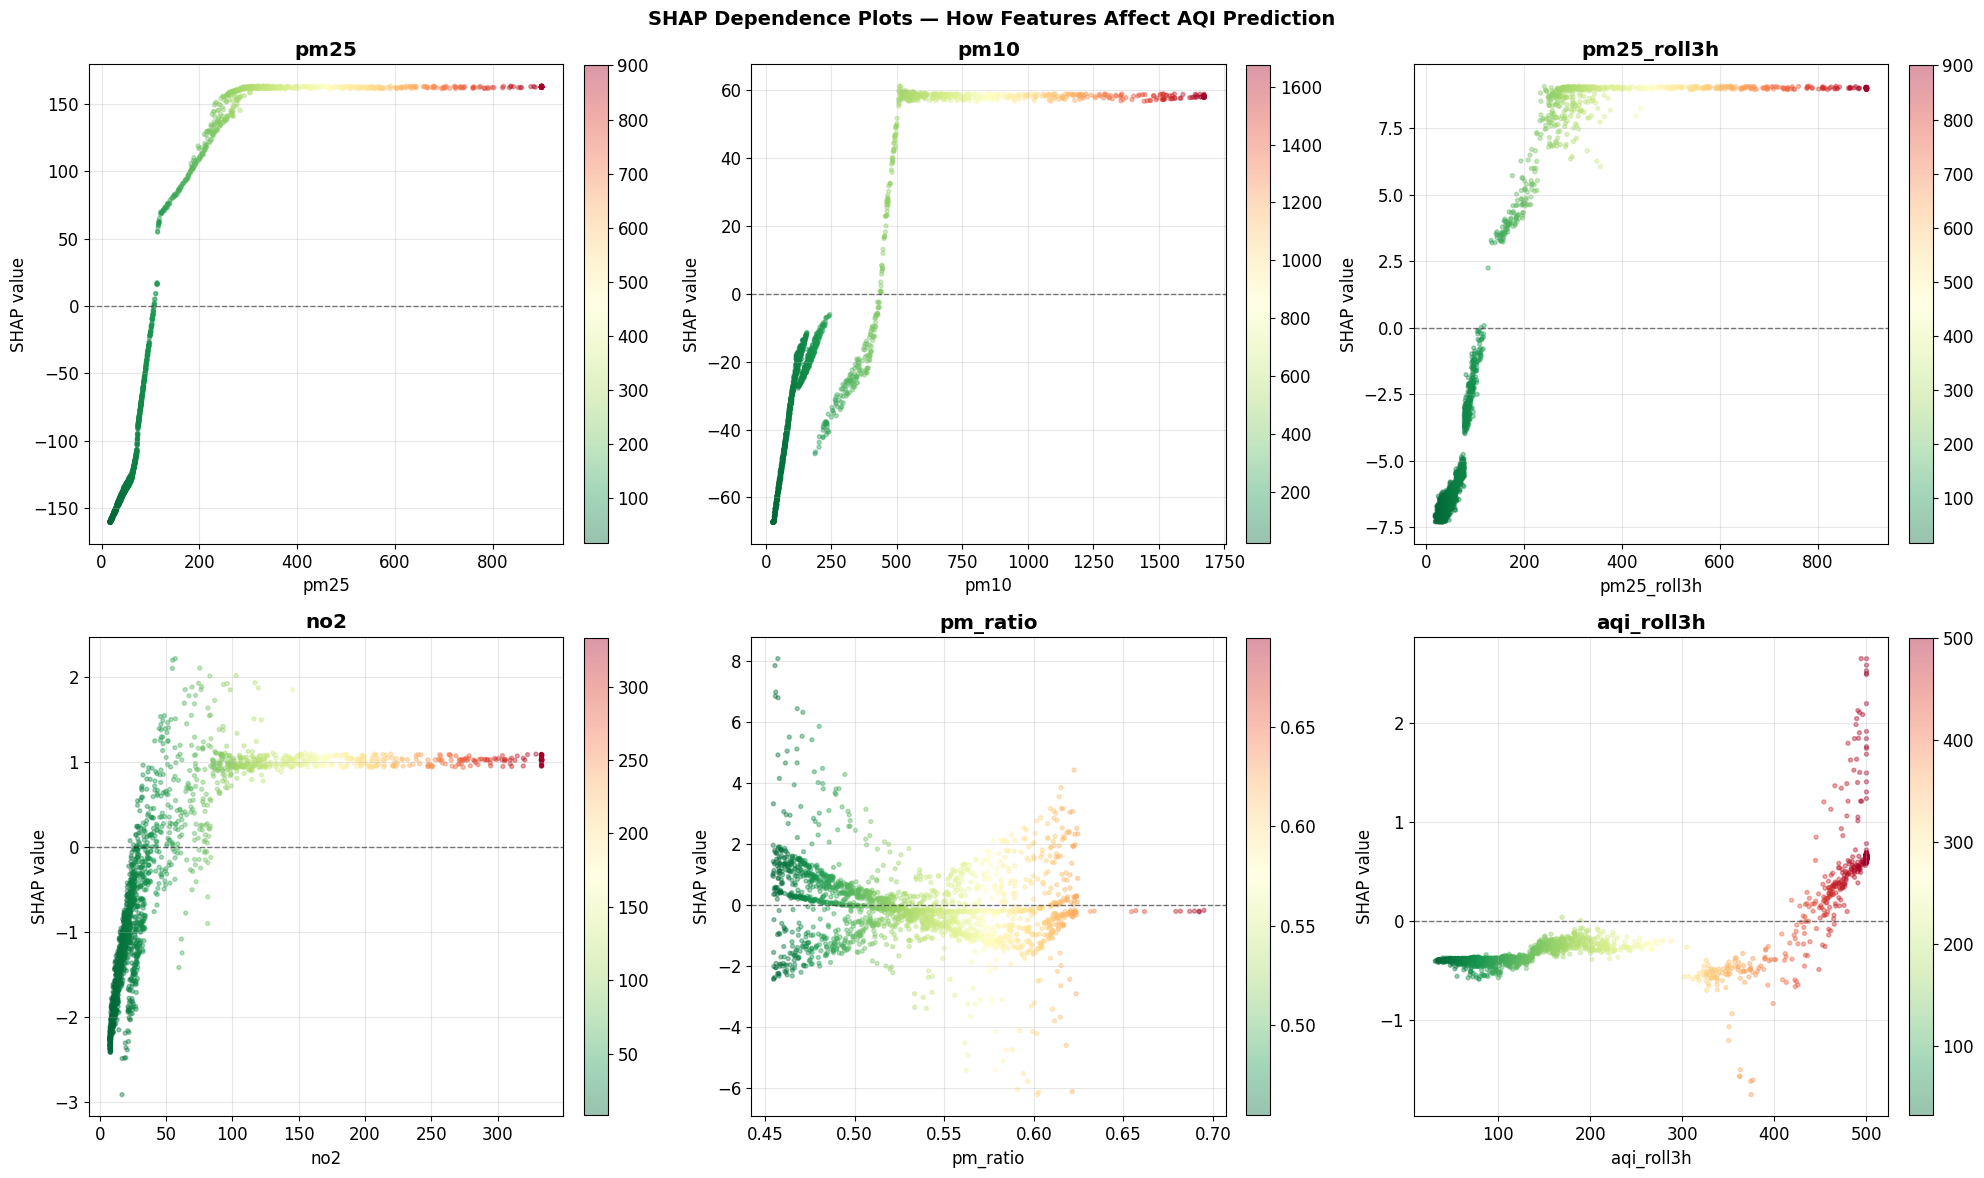

In [31]:
top_shap_features = pd.Series(
    np.abs(shap_values_xgb).mean(axis=0),
    index=feature_cols
).nlargest(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('SHAP Dependence Plots — How Features Affect AQI Prediction', fontsize=14, fontweight='bold')

for ax, feat in zip(axes.flatten(), top_shap_features):
    feat_idx = feature_cols.index(feat)
    shap_vals = shap_values_xgb[:, feat_idx]
    feat_vals = shap_sample[feat].values
    interaction_idx = 'auto'
    scatter = ax.scatter(feat_vals, shap_vals, c=feat_vals,
                         cmap='RdYlGn_r', alpha=0.4, s=8, rasterized=True)
    plt.colorbar(scatter, ax=ax, fraction=0.046, pad=0.04)
    ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    ax.set_xlabel(feat)
    ax.set_ylabel('SHAP value')
    ax.set_title(feat, fontweight='bold')

plt.tight_layout()
plt.show()


Example: High AQI (>300)
Actual AQI: 305.0 | Predicted: 305.1


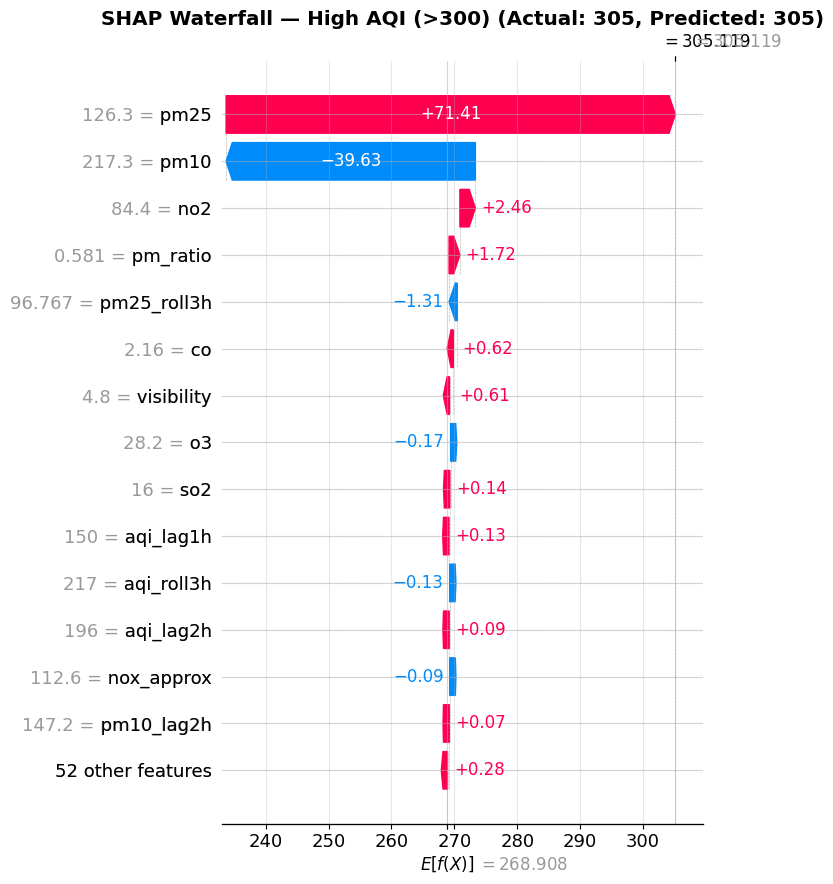


Example: Low AQI (<100)
Actual AQI: 95.0 | Predicted: 95.7


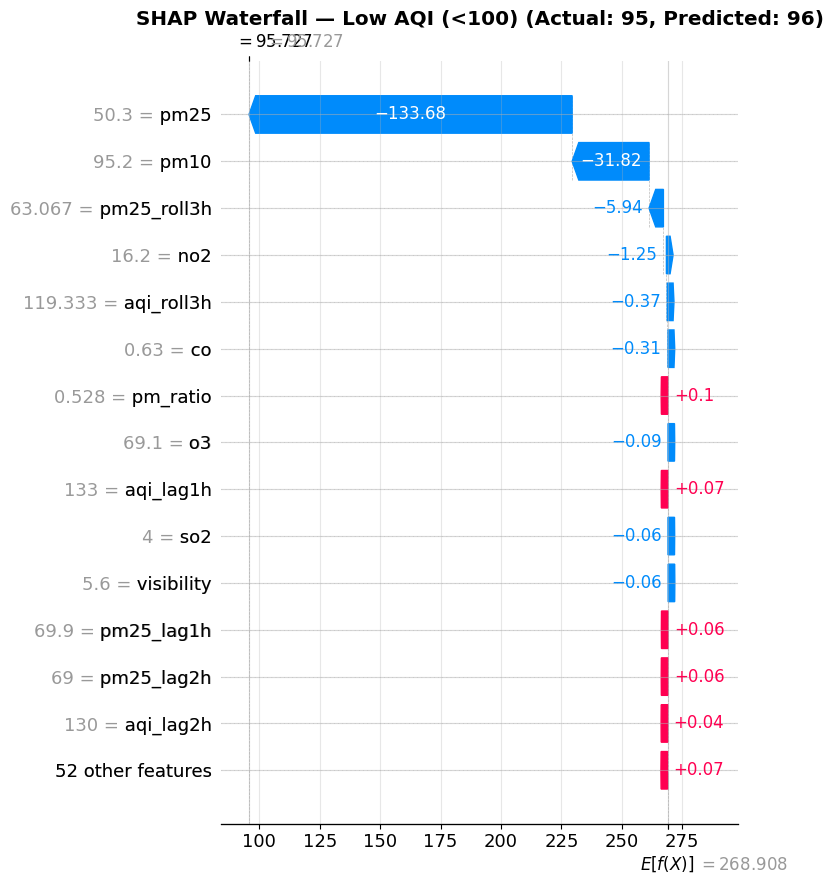

In [32]:
shap_explainer_full = shap.TreeExplainer(xgb_model)

for label, condition in [('High AQI (>300)', y_reg_test > 300), ('Low AQI (<100)', y_reg_test < 100)]:
    idx_pool = np.where(condition)[0]
    if len(idx_pool) == 0:
        continue
    chosen_idx = idx_pool[0]
    sample_point = X_test.iloc[[chosen_idx]]
    shap_vals_single = shap_explainer_full(sample_point)
    actual = y_reg_test.iloc[chosen_idx]
    predicted = xgb_model.predict(sample_point)[0]
    print(f"\n{'='*50}")
    print(f"Example: {label}")
    print(f"Actual AQI: {actual:.1f} | Predicted: {predicted:.1f}")
    print(f"{'='*50}")
    plt.figure(figsize=(14, 6))
    shap.plots.waterfall(shap_vals_single[0], max_display=15, show=False)
    plt.title(f'SHAP Waterfall — {label} (Actual: {actual:.0f}, Predicted: {predicted:.0f})',
              fontweight='bold')
    plt.tight_layout()
    plt.show()

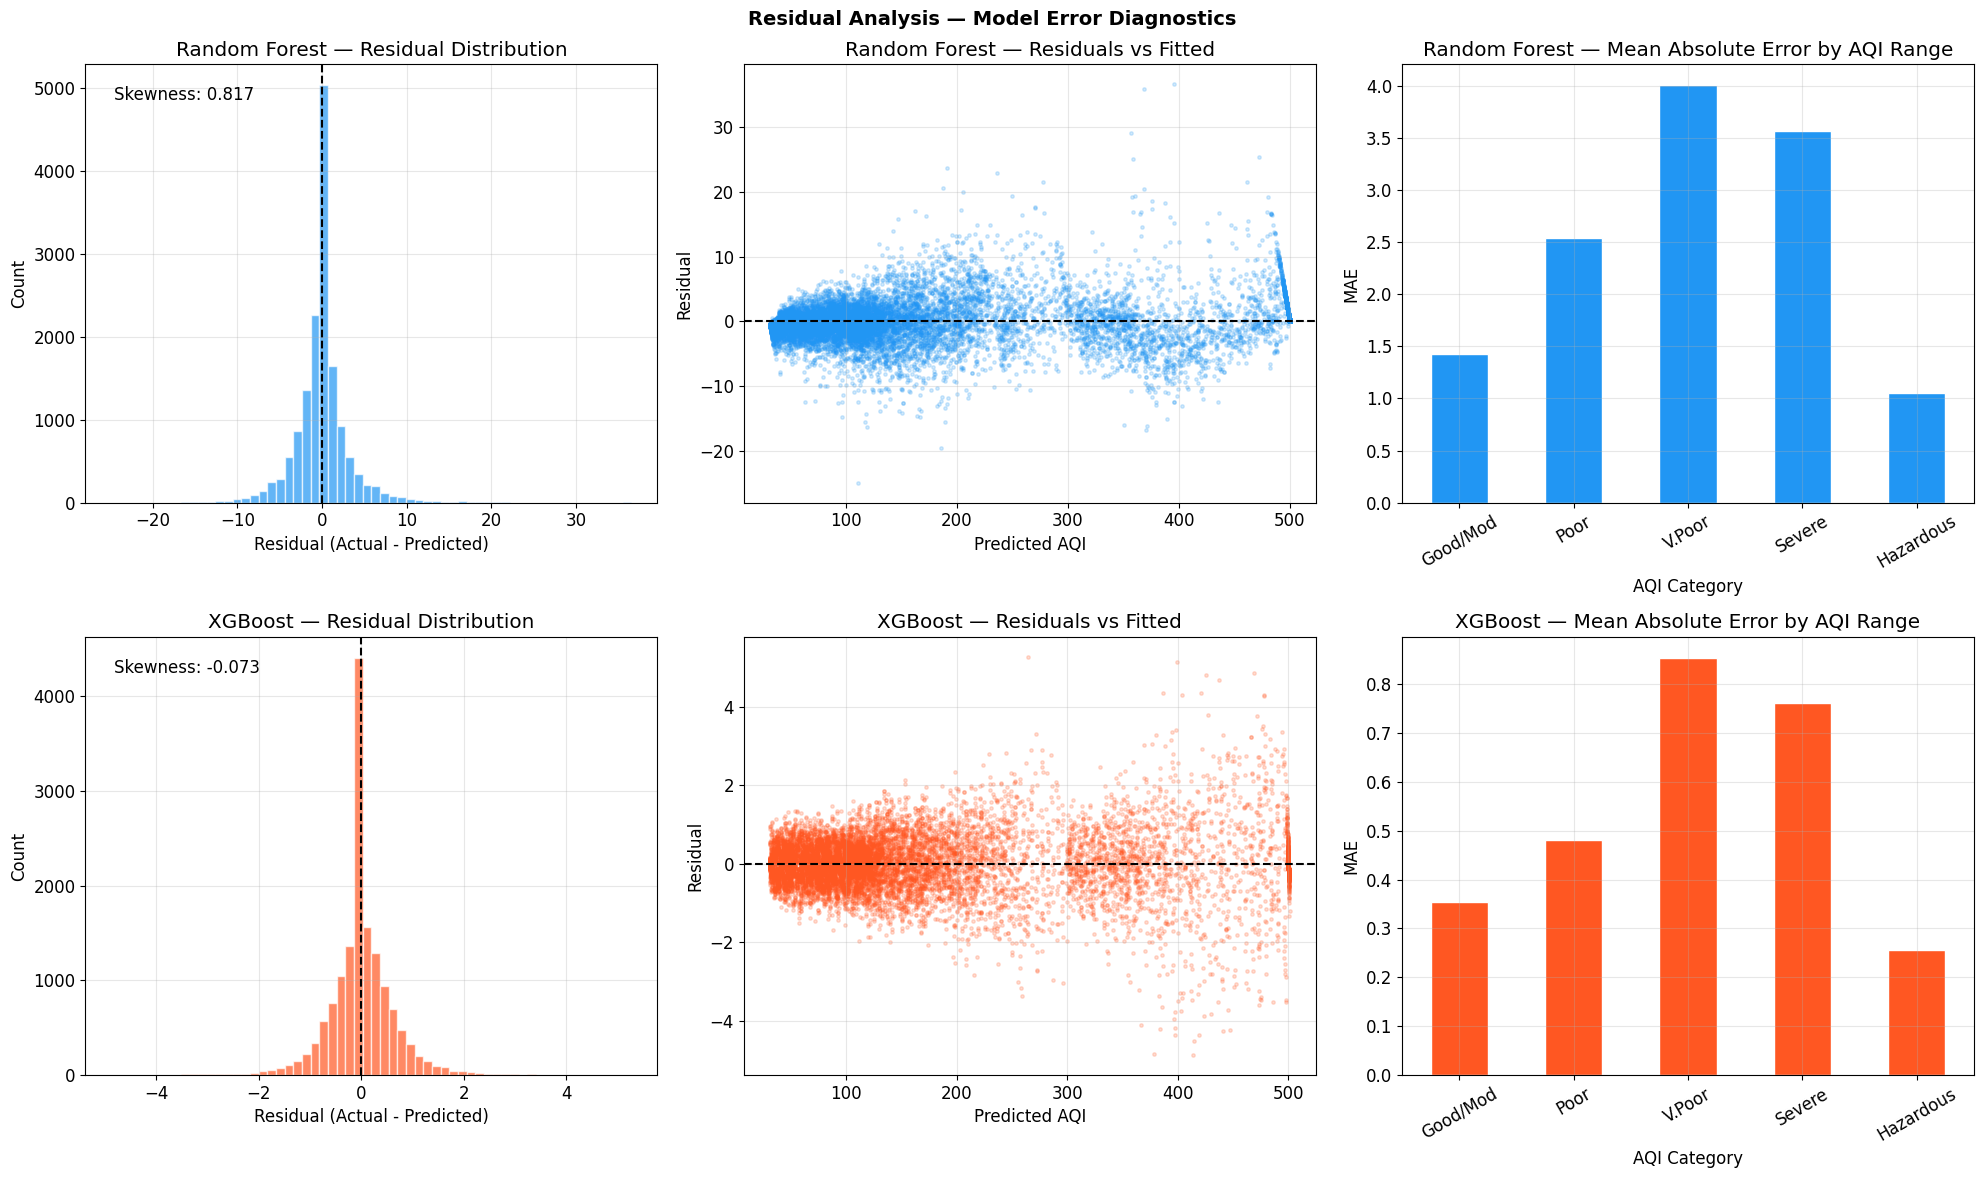

In [35]:
residuals_rf = y_reg_test.values - y_pred_rf_test
residuals_xgb = y_reg_test.values - y_pred_xgb_test

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Residual Analysis — Model Error Diagnostics', fontsize=14, fontweight='bold')

for row, (residuals, name, color) in enumerate([
    (residuals_rf, 'Random Forest', '#2196F3'),
    (residuals_xgb, 'XGBoost', '#FF5722')
]):
    axes[row, 0].hist(residuals, bins=60, color=color, alpha=0.7, edgecolor='white')
    axes[row, 0].axvline(0, color='black', linestyle='--')
    axes[row, 0].set_title(f'{name} — Residual Distribution')
    axes[row, 0].set_xlabel('Residual (Actual - Predicted)')
    axes[row, 0].set_ylabel('Count')
    skewness = pd.Series(residuals).skew()
    axes[row, 0].text(0.05, 0.95, f'Skewness: {skewness:.3f}', transform=axes[row, 0].transAxes, va='top')

    axes[row, 1].scatter(y_pred_rf_test if row == 0 else y_pred_xgb_test,
                         residuals, alpha=0.2, s=6, color=color)
    axes[row, 1].axhline(0, color='black', linestyle='--')
    axes[row, 1].set_xlabel('Predicted AQI')
    axes[row, 1].set_ylabel('Residual')
    axes[row, 1].set_title(f'{name} — Residuals vs Fitted')

    aqi_bins = pd.cut(y_reg_test, bins=[0, 100, 200, 300, 400, 600], labels=['Good/Mod','Poor','V.Poor','Severe','Hazardous'])
    error_by_cat = pd.DataFrame({'error': np.abs(residuals), 'category': aqi_bins}).groupby('category')['error'].mean()
    error_by_cat.plot(kind='bar', ax=axes[row, 2], color=color, edgecolor='white')
    axes[row, 2].set_title(f'{name} — Mean Absolute Error by AQI Range')
    axes[row, 2].set_xlabel('AQI Category')
    axes[row, 2].set_ylabel('MAE')
    axes[row, 2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

=== City-wise Model Performance ===
         City Model     RMSE       R2      MAE  N_samples
  Anand Vihar    RF 3.587619 0.999582 2.122724       1092
  Anand Vihar   XGB 0.666637 0.999986 0.418347       1092
     Wazirpur    RF 3.385158 0.999630 2.040101       1092
     Wazirpur   XGB 0.693678 0.999984 0.433164       1092
     RK Puram    RF 3.083590 0.999700 1.916247       1092
     RK Puram   XGB 0.657854 0.999986 0.428026       1092
       Bawana    RF 3.468382 0.999613 2.123037       1092
       Bawana   XGB 0.658525 0.999986 0.412528       1092
 Jahangirpuri    RF 3.300448 0.999646 2.039736       1092
 Jahangirpuri   XGB 0.619565 0.999988 0.402408       1092
       Rohini    RF 3.099340 0.999694 1.863957       1093
       Rohini   XGB 0.649596 0.999987 0.429529       1093
     Shadipur    RF 3.134937 0.999687 1.930128       1092
     Shadipur   XGB 0.676237 0.999985 0.434288       1092
    Siri Fort    RF 2.827941 0.999745 1.816154       1093
    Siri Fort   XGB 0.691684 0.99998

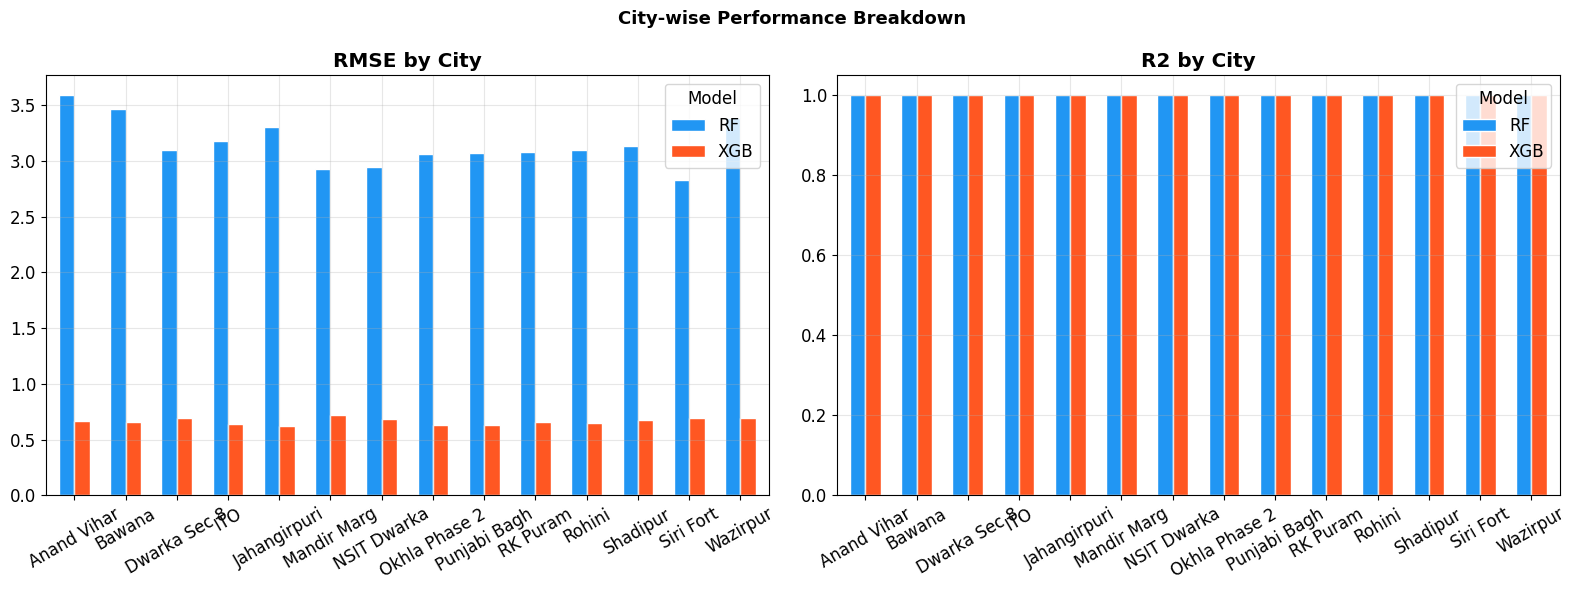

In [36]:
city_perf_rows = []
for city in df_feat['city'].unique():
    city_mask_test = (df_feat.loc[X_test.index, 'city'] == city)
    if city_mask_test.sum() < 10:
        continue
    y_true_city = y_reg_test[city_mask_test]
    y_pred_rf_city = y_pred_rf_test[city_mask_test.values]
    y_pred_xgb_city = y_pred_xgb_test[city_mask_test.values]

    for model_name, y_pred_city in [('RF', y_pred_rf_city), ('XGB', y_pred_xgb_city)]:
        city_perf_rows.append({
            'City': city,
            'Model': model_name,
            'RMSE': np.sqrt(mean_squared_error(y_true_city, y_pred_city)),
            'R2': r2_score(y_true_city, y_pred_city),
            'MAE': mean_absolute_error(y_true_city, y_pred_city),
            'N_samples': len(y_true_city)
        })

city_perf_df = pd.DataFrame(city_perf_rows)
print("=== City-wise Model Performance ===")
print(city_perf_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, metric in zip(axes, ['RMSE', 'R2']):
    pivot = city_perf_df.pivot(index='City', columns='Model', values=metric)
    pivot.plot(kind='bar', ax=ax, edgecolor='white',
               color=['#2196F3', '#FF5722'], width=0.6)
    ax.set_title(f'{metric} by City', fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(title='Model')

plt.suptitle('City-wise Performance Breakdown', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [37]:
import joblib
import json

joblib.dump(rf_model, 'rf_aqi_model.pkl')
joblib.dump(xgb_model, 'xgb_aqi_model.pkl')
joblib.dump(scaler, 'feature_scaler.pkl')
joblib.dump(feature_cols, 'feature_columns.pkl')
joblib.dump(le_cat, 'aqi_label_encoder.pkl')

summary = {
    'random_forest': {
        'test_rmse': rf_test_metrics['RMSE'],
        'test_r2': rf_test_metrics['R2'],
        'test_mae': rf_test_metrics['MAE'],
        'test_mape': rf_test_metrics['MAPE'],
        'n_estimators': 300
    },
    'xgboost': {
        'test_rmse': xgb_test_metrics['RMSE'],
        'test_r2': xgb_test_metrics['R2'],
        'test_mae': xgb_test_metrics['MAE'],
        'test_mape': xgb_test_metrics['MAPE'],
        'best_iteration': int(xgb_model.best_iteration)
    },
    'dataset': {
        'total_records': len(df_feat),
        'train_size': len(X_train),
        'val_size': len(X_val),
        'test_size': len(X_test),
        'n_features': len(feature_cols),
        'cities': list(df_feat['city'].unique()),
        'date_range': f"{df_feat['datetime'].min().date()} to {df_feat['datetime'].max().date()}"
    }
}

with open('model_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("Saved files:")
print("  rf_aqi_model.pkl       — Random Forest regressor")
print("  xgb_aqi_model.pkl      — XGBoost regressor")
print("  feature_scaler.pkl     — StandardScaler")
print("  feature_columns.pkl    — Ordered feature list")
print("  aqi_label_encoder.pkl  — AQI category encoder")
print("  model_summary.json     — Performance summary")
print("\nModel Summary:")
print(json.dumps(summary, indent=2))

Saved files:
  rf_aqi_model.pkl       — Random Forest regressor
  xgb_aqi_model.pkl      — XGBoost regressor
  feature_scaler.pkl     — StandardScaler
  feature_columns.pkl    — Ordered feature list
  aqi_label_encoder.pkl  — AQI category encoder
  model_summary.json     — Performance summary

Model Summary:
{
  "random_forest": {
    "test_rmse": 3.1610990757209585,
    "test_r2": 0.9996810945190678,
    "test_mae": 1.9474858264025765,
    "test_mape": 1.5007547916399304,
    "n_estimators": 300
  },
  "xgboost": {
    "test_rmse": 0.6660761785856795,
    "test_r2": 0.9999858409677271,
    "test_mae": 0.42332943381846727,
    "test_mape": 0.3394631636302422,
    "best_iteration": 498
  },
  "dataset": {
    "total_records": 101976,
    "train_size": 71382,
    "val_size": 15297,
    "test_size": 15297,
    "n_features": 66,
    "cities": [
      "Anand Vihar",
      "Wazirpur",
      "RK Puram",
      "Bawana",
      "Jahangirpuri",
      "Rohini",
      "Shadipur",
      "Siri Fort",

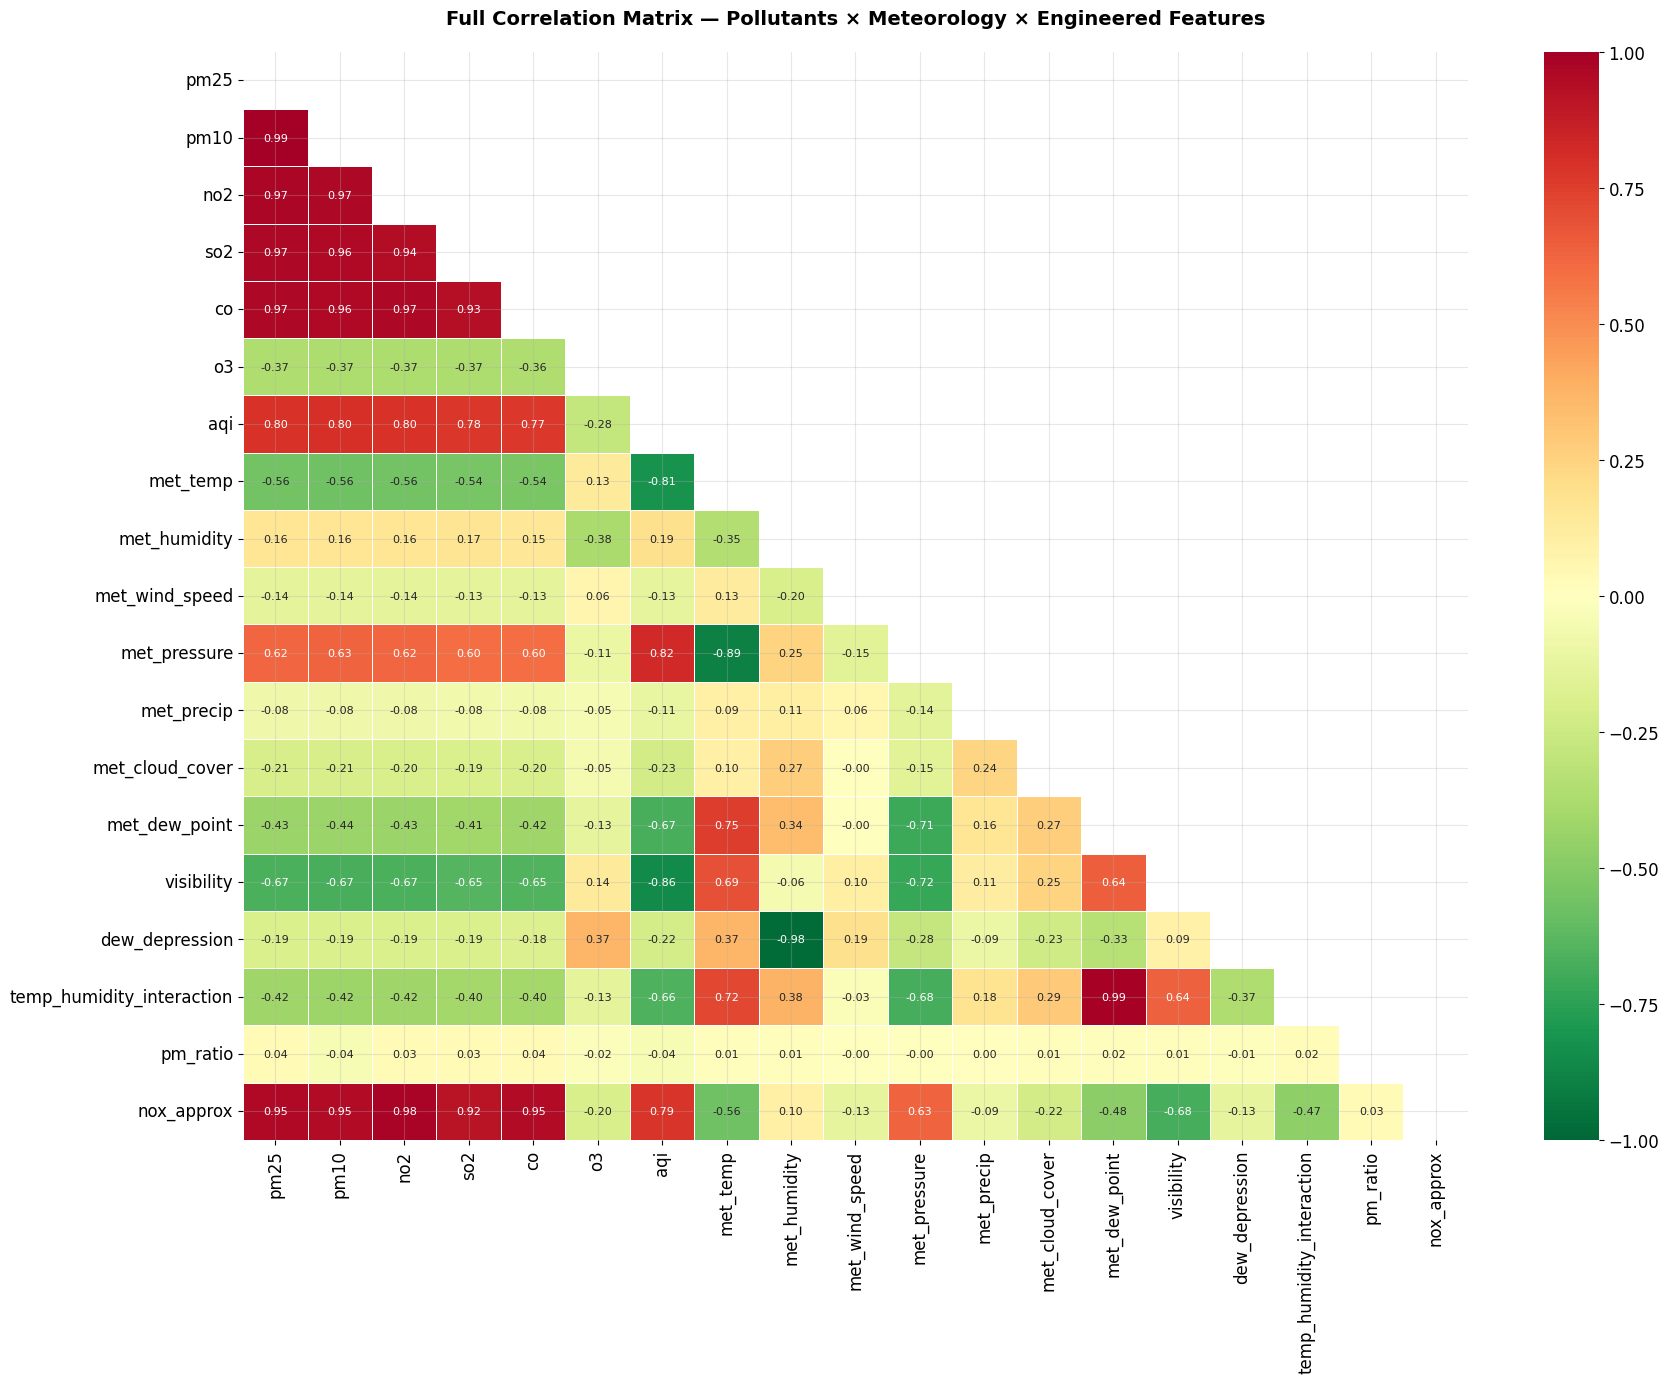

TOP CORRELATIONS WITH AQI
  visibility                          ▼ -0.859  █████████████████████████
  met_pressure                        ▲ +0.822  ████████████████████████
  met_temp                            ▼ -0.814  ████████████████████████
  pm10                                ▲ +0.804  ████████████████████████
  no2                                 ▲ +0.796  ███████████████████████
  pm25                                ▲ +0.795  ███████████████████████
  nox_approx                          ▲ +0.785  ███████████████████████
  so2                                 ▲ +0.775  ███████████████████████
  co                                  ▲ +0.772  ███████████████████████
  met_dew_point                       ▼ -0.672  ████████████████████
  temp_humidity_interaction           ▼ -0.663  ███████████████████
  o3                                  ▼ -0.284  ████████
  met_cloud_cover                     ▼ -0.226  ██████
  dew_depression                      ▼ -0.217  ██████
  met_humidity   

In [38]:
corr_cols = pollutants + ['aqi', 'met_temp', 'met_humidity', 'met_wind_speed',
                           'met_pressure', 'met_precip', 'met_cloud_cover',
                           'met_dew_point', 'visibility', 'dew_depression',
                           'temp_humidity_interaction', 'pm_ratio', 'nox_approx']

corr_cols = [c for c in corr_cols if c in df_feat.columns]
corr_matrix = df_feat[corr_cols].corr()

fig, ax = plt.subplots(figsize=(18, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Full Correlation Matrix — Pollutants × Meteorology × Engineered Features',
             fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("=" * 55)
print("TOP CORRELATIONS WITH AQI")
print("=" * 55)
aqi_corr = corr_matrix['aqi'].drop('aqi').sort_values(key=abs, ascending=False)
for feat, val in aqi_corr.head(15).items():
    bar = '█' * int(abs(val) * 30)
    direction = '▲ +' if val > 0 else '▼ -'
    print(f"  {feat:<35} {direction}{abs(val):.3f}  {bar}")

print("\n" + "=" * 55)
print("TOP CORRELATIONS WITH PM2.5")
print("=" * 55)
pm25_corr = corr_matrix['pm25'].drop('pm25').sort_values(key=abs, ascending=False)
for feat, val in pm25_corr.head(15).items():
    bar = '█' * int(abs(val) * 30)
    direction = '▲ +' if val > 0 else '▼ -'
    print(f"  {feat:<35} {direction}{abs(val):.3f}  {bar}")

print("\n" + "=" * 55)
print("INTER-POLLUTANT CORRELATION SUMMARY")
print("=" * 55)
poll_corr = corr_matrix.loc[pollutants, pollutants]
print(poll_corr.round(3))

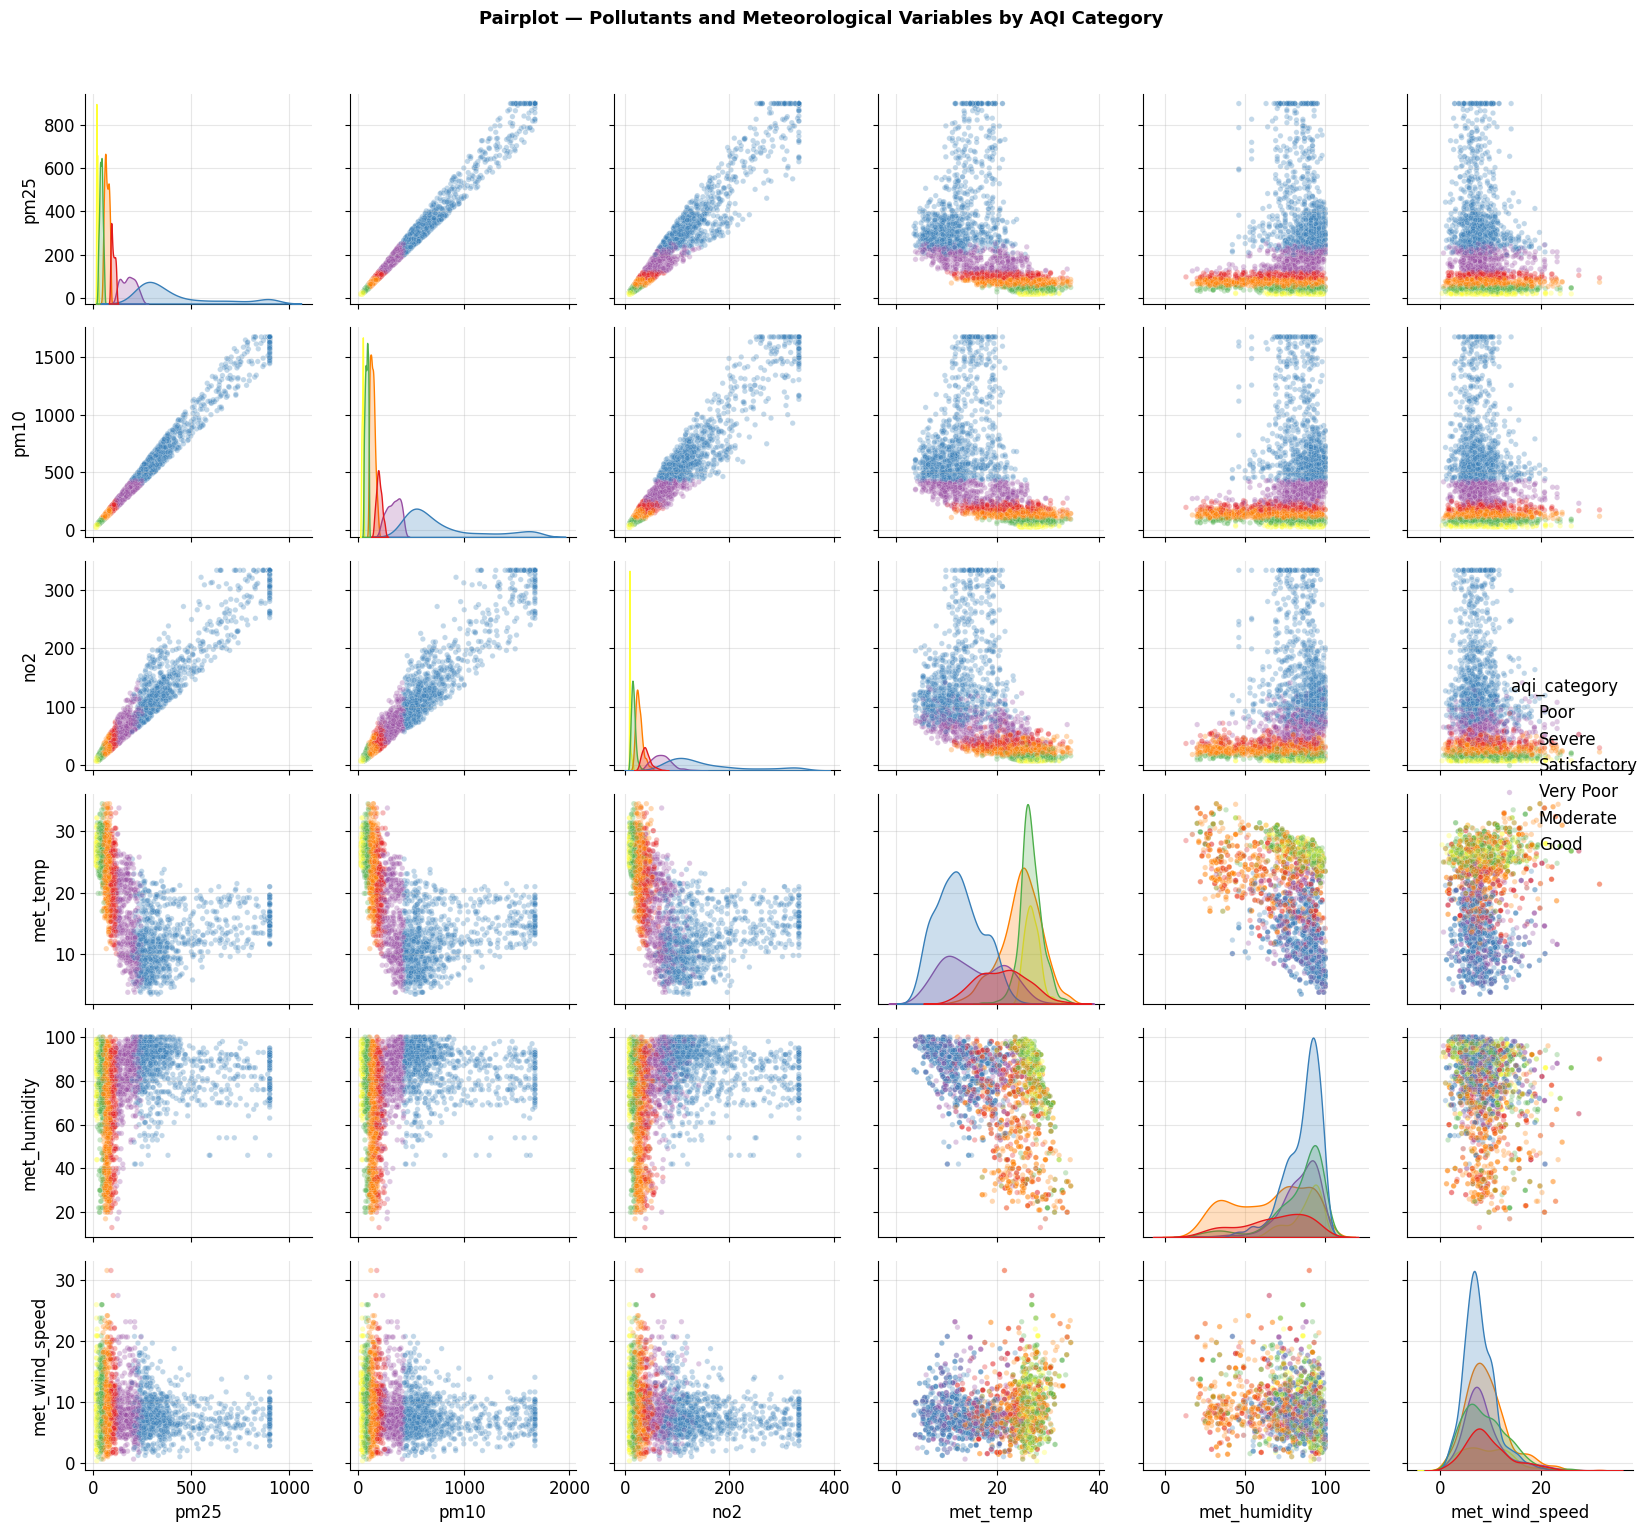

In [39]:
sample_pairplot = df_feat[['pm25','pm10','no2','o3','aqi',
                             'met_temp','met_humidity','met_wind_speed',
                             'aqi_category']].sample(3000, random_state=42)

g = sns.pairplot(sample_pairplot, hue='aqi_category', diag_kind='kde',
                 plot_kws={'alpha': 0.3, 's': 15},
                 palette='Set1',
                 vars=['pm25','pm10','no2','met_temp','met_humidity','met_wind_speed'])
g.fig.suptitle('Pairplot — Pollutants and Meteorological Variables by AQI Category',
               y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

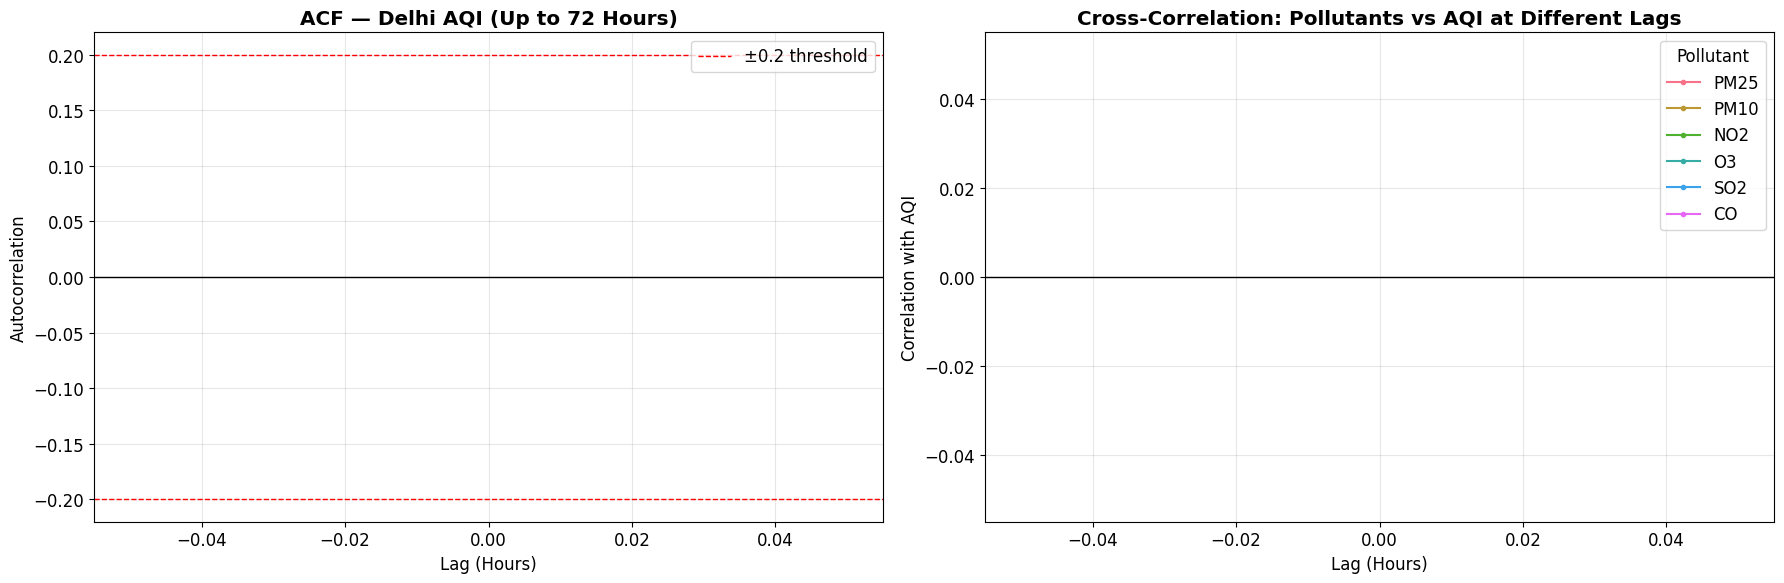


Peak cross-correlations with AQI:
  PM25   peaks at lag=0h  (r=nan)
  PM10   peaks at lag=0h  (r=nan)
  NO2    peaks at lag=0h  (r=nan)
  O3     peaks at lag=0h  (r=nan)
  SO2    peaks at lag=0h  (r=nan)
  CO     peaks at lag=0h  (r=nan)


In [40]:
delhi_aqi = df_feat[df_feat['city'] == 'Delhi']['aqi'].dropna().values

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

from pandas.plotting import autocorrelation_plot
pd.Series(delhi_aqi[:5000]).autocorr

max_lag = 72
acf_vals = [pd.Series(delhi_aqi).autocorr(lag=i) for i in range(1, max_lag+1)]
pacf_lags = list(range(1, max_lag+1))

axes[0].bar(pacf_lags, acf_vals, color=['#2196F3' if v > 0 else '#FF5722' for v in acf_vals],
            alpha=0.7, edgecolor='white')
axes[0].axhline(0, color='black', linewidth=1)
axes[0].axhline(0.2,  color='red',    linestyle='--', linewidth=1, label='±0.2 threshold')
axes[0].axhline(-0.2, color='red',    linestyle='--', linewidth=1)
axes[0].set_xlabel('Lag (Hours)')
axes[0].set_ylabel('Autocorrelation')
axes[0].set_title('ACF — Delhi AQI (Up to 72 Hours)', fontweight='bold')
axes[0].legend()

lag_corr_poll = {}
for poll in ['pm25', 'pm10', 'no2', 'o3', 'so2', 'co']:
    corrs = []
    for lag in range(0, 49):
        shifted = df_feat[df_feat['city']=='Delhi'][poll].shift(lag)
        c = df_feat[df_feat['city']=='Delhi']['aqi'].corr(shifted)
        corrs.append(c)
    lag_corr_poll[poll] = corrs

for poll, corrs in lag_corr_poll.items():
    axes[1].plot(range(0, 49), corrs, marker='o', markersize=3, linewidth=1.5, label=poll.upper())

axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_xlabel('Lag (Hours)')
axes[1].set_ylabel('Correlation with AQI')
axes[1].set_title('Cross-Correlation: Pollutants vs AQI at Different Lags', fontweight='bold')
axes[1].legend(title='Pollutant')
plt.tight_layout()
plt.show()

print("\nPeak cross-correlations with AQI:")
for poll, corrs in lag_corr_poll.items():
    best_lag = np.argmax(np.abs(corrs))
    print(f"  {poll.upper():<6} peaks at lag={best_lag}h  (r={corrs[best_lag]:.3f})")

Feature                                     RF Imp   XGB Imp      Mean  Avg Rank
  pm25                                      0.1339    0.5989    0.3664  █████████████████████████████████████████████████████████████████████████████████████████████████████████████
  pm10                                      0.1307    0.2224    0.1765  ████████████████████████████████████████████████████
  pm25_roll3h                               0.0993    0.1685    0.1339  ████████████████████████████████████████
  aqi_roll3h                                0.0925    0.0009    0.0467  ██████████████
  pm10_roll3h                               0.0706    0.0000    0.0353  ██████████
  no2_roll3h                                0.0596    0.0000    0.0298  ████████
  pm25_roll6h                               0.0512    0.0001    0.0256  ███████
  co                                        0.0405    0.0004    0.0204  ██████
  pm10_roll6h                               0.0384    0.0001    0.0192  █████
  aqi_roll6

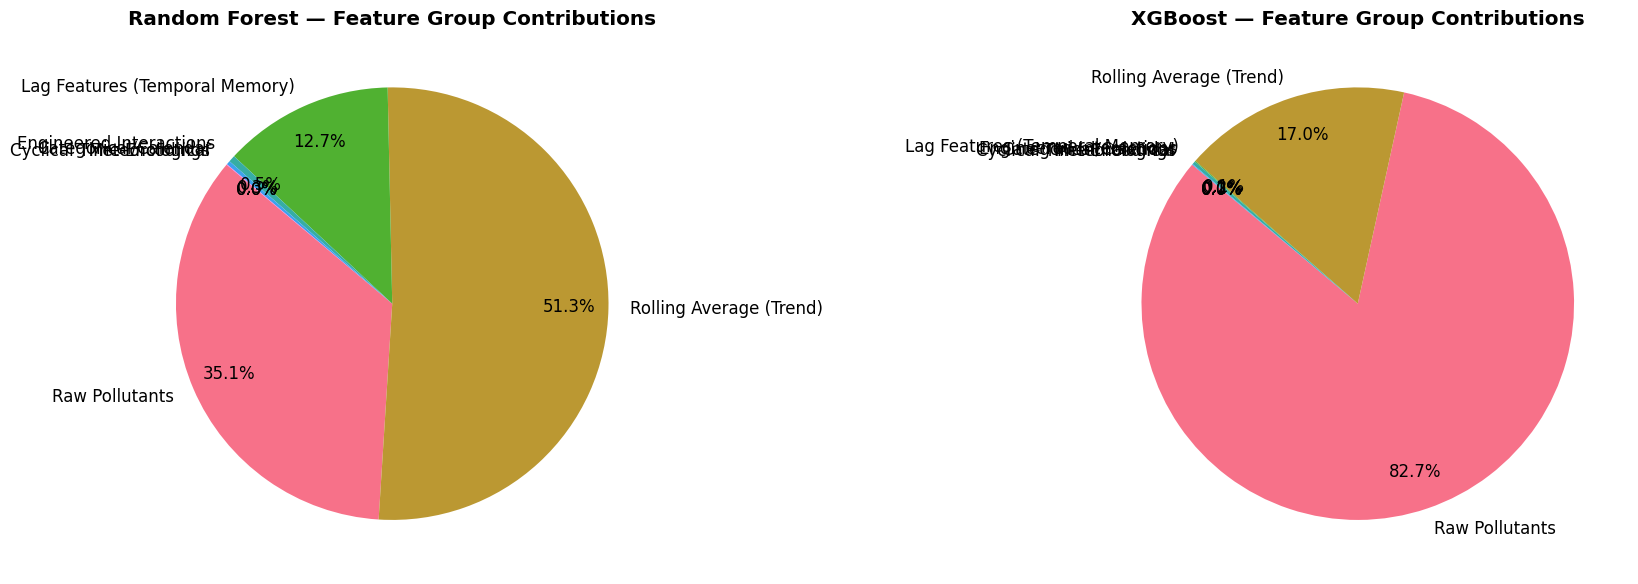


Features in BOTH top-20 (strong consensus):  ['aqi_lag1h', 'aqi_lag2h', 'aqi_roll3h', 'co', 'no2', 'pm10', 'pm10_lag1h', 'pm10_roll6h', 'pm25', 'pm25_lag12h', 'pm25_lag2h', 'pm25_roll3h', 'pm25_roll6h']

Only in RF top-20:  ['aqi_roll24h', 'aqi_roll6h', 'no2_roll3h', 'no2_roll6h', 'pm10_roll3h', 'pm25_lag1h', 'so2']
Only in XGB top-20: ['no2_lag12h', 'nox_approx', 'o3', 'pm10_lag2h', 'pm25_lag24h', 'pm_ratio', 'visibility']


In [41]:
rf_imp   = pd.Series(rf_model.feature_importances_,  index=feature_cols).sort_values(ascending=False)
xgb_imp  = pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values(ascending=False)

combined = pd.DataFrame({'RandomForest': rf_imp, 'XGBoost': xgb_imp})
combined['Mean_Importance'] = combined.mean(axis=1)
combined['Rank_RF']  = rf_imp.rank(ascending=False).astype(int)
combined['Rank_XGB'] = xgb_imp.rank(ascending=False).astype(int)
combined['Rank_Avg'] = combined['Mean_Importance'].rank(ascending=False).astype(int)
combined = combined.sort_values('Mean_Importance', ascending=False)

print("=" * 75)
print(f"{'Feature':<40} {'RF Imp':>9} {'XGB Imp':>9} {'Mean':>9} {'Avg Rank':>9}")
print("=" * 75)
for feat, row in combined.head(30).iterrows():
    bar = '█' * int(row['Mean_Importance'] * 300)
    print(f"  {feat:<38} {row['RandomForest']:>9.4f} {row['XGBoost']:>9.4f} {row['Mean_Importance']:>9.4f}  {bar}")

print("\n\n=== FEATURE GROUP CONTRIBUTIONS ===")
groups = {
    'Lag Features (Temporal Memory)':    [c for c in feature_cols if 'lag'  in c],
    'Rolling Average (Trend)':           [c for c in feature_cols if 'roll' in c],
    'Raw Pollutants':                     pollutants,
    'Meteorological':                    [c for c in feature_cols if 'met_' in c],
    'Cyclical Time Encodings':           [c for c in feature_cols if any(x in c for x in ['sin','cos'])],
    'Engineered Interactions':           ['temp_humidity_interaction','wind_precip_interaction',
                                          'dew_depression','pm_ratio','nox_approx'],
    'Categorical/Calendar':              ['is_weekend','season_code','city_code','station_code','visibility'],
}

group_summary = []
for grp_name, cols in groups.items():
    valid_cols = [c for c in cols if c in feature_cols]
    if not valid_cols:
        continue
    rf_sum  = rf_imp[valid_cols].sum()
    xgb_sum = xgb_imp[valid_cols].sum()
    group_summary.append({
        'Group': grp_name,
        'N Features': len(valid_cols),
        'RF Total %':  round(rf_sum  * 100, 2),
        'XGB Total %': round(xgb_sum * 100, 2),
        'Avg %':       round((rf_sum + xgb_sum) / 2 * 100, 2)
    })

group_df = pd.DataFrame(group_summary).sort_values('Avg %', ascending=False)
print(group_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
axes[0].pie(group_df['RF Total %'],  labels=group_df['Group'], autopct='%1.1f%%',
            startangle=140, pctdistance=0.82)
axes[0].set_title('Random Forest — Feature Group Contributions', fontweight='bold')
axes[1].pie(group_df['XGB Total %'], labels=group_df['Group'], autopct='%1.1f%%',
            startangle=140, pctdistance=0.82)
axes[1].set_title('XGBoost — Feature Group Contributions', fontweight='bold')
plt.tight_layout()
plt.show()

top20_rf  = set(rf_imp.head(20).index)
top20_xgb = set(xgb_imp.head(20).index)
print(f"\nFeatures in BOTH top-20 (strong consensus):  {sorted(top20_rf & top20_xgb)}")
print(f"\nOnly in RF top-20:  {sorted(top20_rf  - top20_xgb)}")
print(f"Only in XGB top-20: {sorted(top20_xgb - top20_rf)}")

Computing permutation importance on test set (this takes ~2 minutes)...


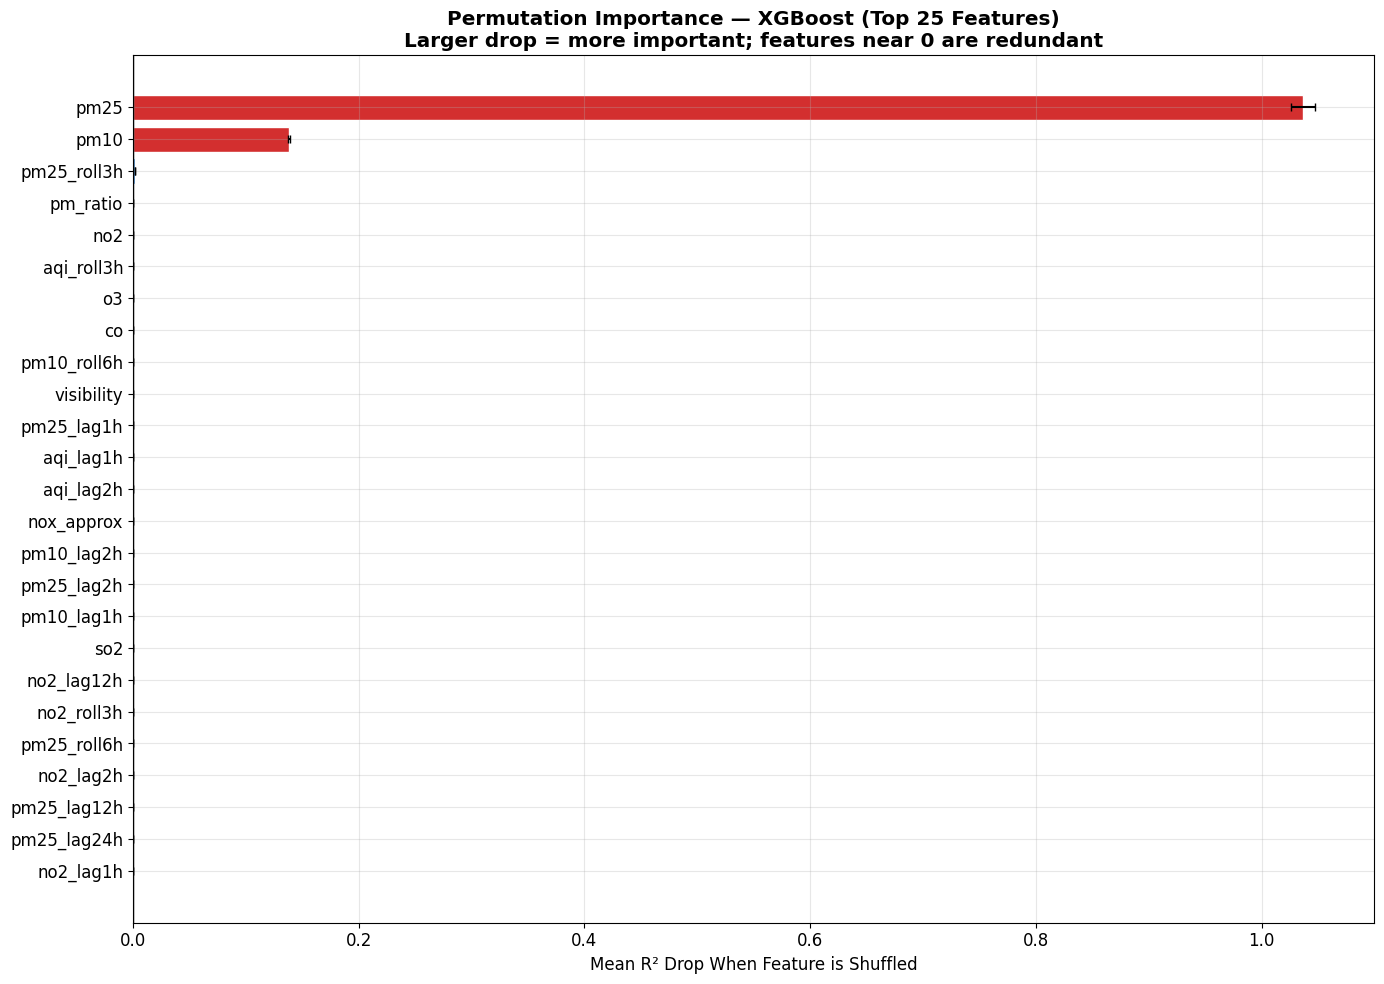


Top 15 permutation importances:
  pm25                                     drop=+1.0367 ± 0.0104  ██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  pm10                                     drop=+0.1382 ± 0.0009  █████████████████████████████████████████████████████████████████████
  pm25_roll3h                              drop=+0.0016 ± 0.0000  
  pm_ratio                                 drop=+0.0004 ± 0.0000  
  no2                                      drop=+0.0002 ± 0.0000  
  aqi_roll3h                               dr

In [42]:
from sklearn.inspection import permutation_importance

print("Computing permutation importance on test set (this takes ~2 minutes)...")

perm_result = permutation_importance(
    xgb_model, X_test, y_reg_test,
    n_repeats=10, random_state=42, n_jobs=-1,
    scoring='r2'
)

perm_imp = pd.DataFrame({
    'Feature':   feature_cols,
    'Mean_Drop': perm_result.importances_mean,
    'Std':       perm_result.importances_std
}).sort_values('Mean_Drop', ascending=False).head(25)

fig, ax = plt.subplots(figsize=(14, 10))
colors = ['#d32f2f' if v > 0.01 else '#1976D2' if v > 0 else '#90A4AE'
          for v in perm_imp['Mean_Drop']]
bars = ax.barh(perm_imp['Feature'][::-1], perm_imp['Mean_Drop'][::-1],
               xerr=perm_imp['Std'][::-1], color=colors[::-1],
               edgecolor='white', capsize=3)
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Mean R² Drop When Feature is Shuffled')
ax.set_title('Permutation Importance — XGBoost (Top 25 Features)\n'
             'Larger drop = more important; features near 0 are redundant',
             fontweight='bold')
plt.tight_layout()
plt.show()

print("\nTop 15 permutation importances:")
for _, row in perm_imp.head(15).iterrows():
    bar = '█' * max(0, int(row['Mean_Drop'] * 500))
    print(f"  {row['Feature']:<40} drop={row['Mean_Drop']:+.4f} ± {row['Std']:.4f}  {bar}")

tree_top15 = set(pd.Series(xgb_model.feature_importances_,
                            index=feature_cols).nlargest(15).index)
perm_top15 = set(perm_imp.head(15)['Feature'])
print(f"\nAgreement between tree-based and permutation top-15: {len(tree_top15 & perm_top15)}/15 features")

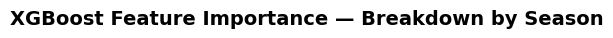

In [43]:
fig, axes = plt.subplots(2, 3, figsize=(22, 14))
fig.suptitle('XGBoost Feature Importance — Breakdown by Season', fontsize=14, fontweight='bold')

seasons_ordered = ['winter', 'spring', 'summer', 'monsoon', 'post-monsoon']
season_palette  = ['#1565C0', '#43A047', '#E53935', '#00838F', '#F57F17']

for ax, (season, color) in zip(axes.flatten(), zip(seasons_ordered, season_palette)):
    mask = df_feat['season'] == season
    X_s  = df_feat.loc[mask, feature_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
    y_s  = pd.to_numeric(df_feat.loc[mask, 'aqi'], errors='coerce').dropna()
    X_s  = X_s.loc[y_s.index]
    if len(X_s) < 100:
        ax.set_visible(False)
        continue
    xgb_s = xgb.XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1,
                               n_jobs=-1, random_state=42, verbosity=0)
    xgb_s.fit(X_s, y_s)
    imp_s = pd.Series(xgb_s.feature_importances_, index=feature_cols).nlargest(12).sort_values()
    ax.barh(imp_s.index, imp_s.values, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(f'{season.title()} (n={len(X_s):,})', fontweight='bold')
    ax.set_xlabel('Importance')

axes[1, 2].set_visible(False)
plt.tight_layout()
plt.show()

In [44]:
def predict_aqi_custom(input_dict):
    base = df_feat[feature_cols].median().to_dict()
    base.update(input_dict)

    raw = {
        'pm25': input_dict.get('pm25', df_feat['pm25'].median()),
        'pm10': input_dict.get('pm10', df_feat['pm10'].median()),
        'no2':  input_dict.get('no2',  df_feat['no2'].median()),
        'aqi':  df_feat['aqi'].median()
    }

    for poll, val in raw.items():
        for lag in [1, 2, 3, 6, 12, 24]:
            base[f'{poll}_lag{lag}h']  = val
        base[f'{poll}_roll3h']  = val
        base[f'{poll}_roll6h']  = val
        base[f'{poll}_roll24h'] = val

    hour  = input_dict.get('hour', 12)
    month = input_dict.get('month', 1)
    base['hour_sin']  = np.sin(2 * np.pi * hour  / 24)
    base['hour_cos']  = np.cos(2 * np.pi * hour  / 24)
    base['month_sin'] = np.sin(2 * np.pi * month / 12)
    base['month_cos'] = np.cos(2 * np.pi * month / 12)

    met_t = input_dict.get('met_temp',     df_feat['met_temp'].median())
    met_h = input_dict.get('met_humidity', df_feat['met_humidity'].median())
    met_w = input_dict.get('met_wind_speed', df_feat['met_wind_speed'].median())
    met_p = input_dict.get('met_precip',   0.0)
    met_d = input_dict.get('met_dew_point', df_feat['met_dew_point'].median())

    base['temp_humidity_interaction'] = met_t * met_h
    base['wind_precip_interaction']   = met_w * (met_p + 0.001)
    base['dew_depression']            = met_t - met_d
    base['pm_ratio']                  = raw['pm25'] / (raw['pm10'] + 0.001)
    base['nox_approx']                = input_dict.get('no2', df_feat['no2'].median()) + \
                                         input_dict.get('o3',  df_feat['o3'].median())

    X_input = pd.DataFrame([base])[feature_cols].apply(pd.to_numeric, errors='coerce').fillna(0)

    pred_rf  = rf_model.predict(X_input)[0]
    pred_xgb = xgb_model.predict(X_input)[0]
    pred_avg = (pred_rf + pred_xgb) / 2

    if pred_avg <= 50:    cat, color = 'Good',       '\033[92m'
    elif pred_avg <= 100: cat, color = 'Satisfactory','\033[92m'
    elif pred_avg <= 200: cat, color = 'Moderate',   '\033[93m'
    elif pred_avg <= 300: cat, color = 'Poor',        '\033[91m'
    elif pred_avg <= 400: cat, color = 'Very Poor',   '\033[91m'
    else:                 cat, color = 'Severe',      '\033[31m'
    reset = '\033[0m'

    print("\n" + "═"*55)
    print("        🌫️  AQI PREDICTION RESULT")
    print("═"*55)
    print(f"  Random Forest  prediction : {pred_rf:.1f}")
    print(f"  XGBoost        prediction : {pred_xgb:.1f}")
    print(f"  Ensemble avg   prediction : {pred_avg:.1f}")
    print(f"\n  Category  → {color}{cat}{reset}")
    print("═"*55)

    health_advice = {
        'Good':        'Air quality is satisfactory. No restrictions.',
        'Satisfactory':'Acceptable quality. Sensitive groups should limit outdoor exertion.',
        'Moderate':    'Sensitive groups may experience symptoms. Reduce prolonged outdoor activity.',
        'Poor':        'Everyone may experience effects. Avoid outdoor exertion.',
        'Very Poor':   'Health alert. Everyone should avoid outdoor activity.',
        'Severe':      '⚠️ Emergency conditions. Stay indoors. Use air purifiers.'
    }
    print(f"\n  Health Advisory:\n  {health_advice[cat]}")
    print("═"*55)

    shap_input = X_input.copy()
    shap_single = shap_explainer_full(shap_input)
    top_shap = pd.Series(shap_single.values[0], index=feature_cols).abs().nlargest(10)

    print("\n  Top 10 driving factors for this prediction:")
    print(f"  {'Feature':<40} {'SHAP':>8}  Direction")
    print("  " + "-"*60)
    for feat, _ in top_shap.items():
        val = shap_single.values[0][feature_cols.index(feat)]
        direction = '▲ raises AQI' if val > 0 else '▼ lowers AQI'
        feat_val  = X_input[feat].values[0]
        print(f"  {feat:<40} {val:>+8.3f}  {direction}  (value={feat_val:.2f})")

    return {'rf': pred_rf, 'xgb': pred_xgb, 'ensemble': pred_avg, 'category': cat}

In [ ]:
print("SCENARIO ANALYSIS — How Each Variable Shifts AQI Prediction")
print("="*65)

baseline = {
    'pm25': 120, 'pm10': 200, 'no2': 60, 'so2': 20, 'co': 2.0, 'o3': 25,
    'met_temp': 18, 'met_humidity': 75, 'met_wind_speed': 5,
    'met_precip': 0, 'met_dew_point': 10, 'met_pressure': 1010,
    'visibility': 2, 'hour': 9, 'month': 1, 'is_weekend': 0, 'city_code': 0, 'season_code': 0
}

def quick_predict(d):
    base = df_feat[feature_cols].median().to_dict()
    base.update(d)
    raw = {k: d.get(k, df_feat[k].median()) for k in ['pm25','pm10','no2','aqi']}
    for poll, val in raw.items():
        for lag in [1,2,3,6,12,24]:
            base[f'{poll}_lag{lag}h'] = val
        for w in [3,6,24]:
            base[f'{poll}_roll{w}h'] = val
    base['hour_sin']  = np.sin(2*np.pi*d.get('hour',12)/24)
    base['hour_cos']  = np.cos(2*np.pi*d.get('hour',12)/24)
    base['month_sin'] = np.sin(2*np.pi*d.get('month',1)/12)
    base['month_cos'] = np.cos(2*np.pi*d.get('month',1)/12)
    base['temp_humidity_interaction'] = d.get('met_temp',20) * d.get('met_humidity',60)
    base['wind_precip_interaction']   = d.get('met_wind_speed',8) * (d.get('met_precip',0)+0.001)
    base['dew_depression']  = d.get('met_temp',20) - d.get('met_dew_point',10)
    base['pm_ratio']        = d.get('pm25',100) / (d.get('pm10',150)+0.001)
    base['nox_approx']      = d.get('no2',40) + d.get('o3',30)
    X_in = pd.DataFrame([base])[feature_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
    return (rf_model.predict(X_in)[0] + xgb_model.predict(X_in)[0]) / 2

base_aqi = quick_predict(baseline)
print(f"\nBaseline AQI: {base_aqi:.1f}\n")

scenarios = {
    'Double wind speed (10→20 km/h)':      {**baseline, 'met_wind_speed': 20},
    'Heavy rain (10mm precip)':             {**baseline, 'met_precip': 10},
    'Diwali night (PM2.5=400, PM10=600)':   {**baseline, 'pm25': 400, 'pm10': 600},
    'Winter morning (temp=5°C, hum=95%)':   {**baseline, 'met_temp': 5, 'met_humidity': 95},
    'Summer afternoon (temp=42°C, wind=15)':{**baseline, 'met_temp': 42, 'met_wind_speed': 15},
    'PM2.5 drops to 30 (clean day)':        {**baseline, 'pm25': 30},
    'NO₂ triples (heavy traffic)':          {**baseline, 'no2': 180},
    'Low visibility fog (0.5 km)':          {**baseline, 'visibility': 0.5},
    'Weekend vs Weekday':                   {**baseline, 'is_weekend': 1},
    'Midnight (hour=0)':                    {**baseline, 'hour': 0},
}

scenario_results = []
for name, config in scenarios.items():
    pred = quick_predict(config)
    delta = pred - base_aqi
    scenario_results.append({'Scenario': name, 'Predicted AQI': pred, 'Change': delta})

scen_df = pd.DataFrame(scenario_results).sort_values('Change', ascending=False)

fig, ax = plt.subplots(figsize=(14, 8))
colors = ['#d32f2f' if v > 0 else '#388e3c' for v in scen_df['Change']]
bars = ax.barh(scen_df['Scenario'], scen_df['Change'], color=colors, edgecolor='white', height=0.6)
ax.axvline(0, color='black', linewidth=1.5)

for bar, (_, row) in zip(bars, scen_df.iterrows()):
    label = f"AQI={row['Predicted AQI']:.0f}  ({row['Change']:+.0f})"
    x_pos = bar.get_width() + (2 if bar.get_width() >= 0 else -2)
    ha = 'left' if bar.get_width() >= 0 else 'right'
    ax.text(x_pos, bar.get_y() + bar.get_height()/2, label, va='center', fontsize=9, ha=ha)

ax.set_xlabel('Change in Predicted AQI from Baseline')
ax.set_title(f'What-If Scenario Analysis  (Baseline AQI = {base_aqi:.0f})', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()
print("\nFull scenario table:")
print(scen_df.to_string(index=False))

In [56]:
monthly = df_feat.groupby(['year','month'])['aqi'].agg(['mean','std','min','max']).reset_index()
monthly['date'] = pd.to_datetime(monthly[['year','month']].assign(day=1))
monthly['z_score'] = (monthly['mean'] - monthly['mean'].rolling(12, min_periods=3).mean()) / \
                      monthly['mean'].rolling(12, min_periods=3).std()
monthly['anomaly'] = monthly['z_score'].abs() > 1.5

fig, axes = plt.subplots(3, 1, figsize=(18, 16))
fig.suptitle('AQI Trend Analysis with Anomaly Detection', fontsize=14, fontweight='bold')

axes[0].fill_between(monthly['date'], monthly['mean'] - monthly['std'],
                     monthly['mean'] + monthly['std'], alpha=0.2, color='#2196F3', label='±1 Std')
axes[0].plot(monthly['date'], monthly['mean'], color='#2196F3', linewidth=2, label='Monthly Mean AQI')
axes[0].scatter(monthly[monthly['anomaly']]['date'],
                monthly[monthly['anomaly']]['mean'],
                color='red', s=80, zorder=5, label='Anomaly (|z|>1.5)')
axes[0].axhline(200, color='orange', linestyle='--', alpha=0.7, label='Poor threshold')
axes[0].axhline(300, color='red',    linestyle='--', alpha=0.7, label='Very Poor threshold')
axes[0].set_ylabel('Average AQI')
axes[0].set_title('Monthly Average AQI with Anomaly Flags', fontweight='bold')
axes[0].legend(loc='upper right')

for city in df_feat['city'].unique():
    city_m = df_feat[df_feat['city']==city].groupby('month')['aqi'].mean()
    axes[1].plot(city_m.index, city_m.values, marker='o', linewidth=2, label=city)
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Average AQI')
axes[1].set_xticks(range(1,13))
axes[1].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
axes[1].set_title('Seasonal AQI Pattern by City (Monthly Average)', fontweight='bold')
axes[1].legend(title='City')

hourly_season = df_feat.groupby(['season','hour'])['aqi'].mean().unstack(level=0)
season_cols = [c for c in ['winter','spring','summer','monsoon','post-monsoon'] if c in hourly_season.columns]
for season in season_cols:
    axes[2].plot(hourly_season.index, hourly_season[season], marker='o',
                 markersize=4, linewidth=2, label=season.title())
axes[2].set_xlabel('Hour of Day')
axes[2].set_ylabel('Average AQI')
axes[2].set_title('Diurnal AQI Pattern by Season (All NCR Cities)', fontweight='bold')
axes[2].set_xticks(range(0,24,2))
axes[2].legend(title='Season')

plt.tight_layout()
plt.show()

print("\nDetected Anomaly Months:")
print(monthly[monthly['anomaly']][['date','mean','z_score']].to_string(index=False))

ValueError: cannot assemble the datetimes: time data "10101" doesn't match format "%Y%m%d", at position 0. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [57]:
import ipywidgets as w
from IPython.display import display
import numpy as np
import pandas as pd

style  = {'description_width': '180px'}
layout = w.Layout(width='380px')

def num(desc, val, mn, mx, step=1):
    return w.BoundedFloatText(value=val, min=mn, max=mx, step=step,
                              description=desc, style=style, layout=layout)

# ── inputs ────────────────────────────────────────────────────
pm25   = num('PM2.5 (µg/m³)',     80,   0,   600, 1)
pm10   = num('PM10 (µg/m³)',     120,   0,   900, 1)
no2    = num('NO₂ (µg/m³)',       40,   0,   300, 0.5)
so2    = num('SO₂ (µg/m³)',       15,   0,   200, 0.5)
co     = num('CO (mg/m³)',         1.5,  0,    20, 0.1)
o3     = num('O₃ (µg/m³)',        30,   0,   200, 0.5)
temp   = num('Temperature (°C)',  22,  -5,    48, 0.5)
hum    = num('Humidity (%)',       60,   5,   100, 1)
wind   = num('Wind speed (km/h)',   8,   0,    60, 0.5)
precip = num('Precipitation (mm)', 0,   0,    50, 0.1)
dew    = num('Dew point (°C)',     12, -10,    35, 0.5)
press  = num('Pressure (hPa)',   1010, 980,  1025, 0.5)
vis    = num('Visibility (km)',     3,   0,    10, 0.1)
hour   = w.BoundedIntText(value=12, min=0, max=23, description='Hour (0–23)',  style=style, layout=layout)
month  = w.BoundedIntText(value=4,  min=1, max=12, description='Month (1–12)', style=style, layout=layout)
city   = w.Dropdown(options=[('Delhi',0),('Noida',1),('Gurugram',2),('Faridabad',3),('Ghaziabad',4)],
                    description='City', style=style, layout=layout)
weekend= w.Dropdown(options=[('Weekday',0),('Weekend',1)],
                    description='Day type', style=style, layout=layout)

predict_btn = w.Button(description='Predict next 7 days', button_style='primary',
                       layout=w.Layout(width='260px', margin='14px 0 0 0'))
out = w.Output()

col1 = w.VBox([w.HTML('<b>Pollutants</b>'),      pm25, pm10, no2, so2, co, o3])
col2 = w.VBox([w.HTML('<b>Meteorology</b>'),     temp, hum, wind, precip, dew, press, vis])
col3 = w.VBox([w.HTML('<b>Date / Location</b>'), hour, month, city, weekend])

display(w.HBox([col1, col2, col3]))
display(predict_btn)
display(out)

# ── autoregressive forecast ───────────────────────────────────
def run_autoregressive_forecast():
    m = month.value
    season = (0 if m in [12,1,2] else 1 if m in [3,4]
              else 2 if m in [5,6] else 3 if m in [7,8,9] else 4)

    # seed history with today's observed values
    aqi_history  = [df_feat['aqi'].median()] * 24
    pm25_history = [pm25.value] * 24
    pm10_history = [pm10.value] * 24
    no2_history  = [no2.value]  * 24

    results = []

    for d in range(7):
        is_wknd      = 1 if ((weekend.value + d + 1) % 7) >= 5 else 0
        forecast_hour = 12

        base = df_feat[feature_cols].median().to_dict()

        # current observed conditions
        base.update({
            'pm25': pm25.value, 'pm10': pm10.value,
            'no2':  no2.value,  'so2':  so2.value,
            'co':   co.value,   'o3':   o3.value,
            'met_temp':        temp.value,
            'met_humidity':    hum.value,
            'met_wind_speed':  wind.value,
            'met_precip':      precip.value,
            'met_dew_point':   dew.value,
            'met_pressure':    press.value,
            'visibility':      vis.value,
            'hour':            forecast_hour,
            'month':           m,
            'is_weekend':      is_wknd,
            'city_code':       city.value,
            'season_code':     season,
            'temperature':     temp.value,
            'humidity':        hum.value,
            'wind_speed':      wind.value,
        })

        # lag features from rolling history
        for lag in [1, 2, 3, 6, 12, 24]:
            idx = min(lag, len(aqi_history) - 1)
            base[f'aqi_lag{lag}h']  = aqi_history[idx]
            base[f'pm25_lag{lag}h'] = pm25_history[idx]
            base[f'pm10_lag{lag}h'] = pm10_history[idx]
            base[f'no2_lag{lag}h']  = no2_history[idx]

        # rolling averages
        base['aqi_roll3h']   = np.mean(aqi_history[:3])
        base['aqi_roll6h']   = np.mean(aqi_history[:6])
        base['aqi_roll24h']  = np.mean(aqi_history[:24])
        base['pm25_roll3h']  = np.mean(pm25_history[:3])
        base['pm25_roll6h']  = np.mean(pm25_history[:6])
        base['pm25_roll24h'] = np.mean(pm25_history[:24])
        base['pm10_roll3h']  = np.mean(pm10_history[:3])
        base['pm10_roll6h']  = np.mean(pm10_history[:6])
        base['pm10_roll24h'] = np.mean(pm10_history[:24])
        base['no2_roll3h']   = np.mean(no2_history[:3])
        base['no2_roll6h']   = np.mean(no2_history[:6])
        base['no2_roll24h']  = np.mean(no2_history[:24])

        # time encodings
        base['hour_sin']  = np.sin(2 * np.pi * forecast_hour / 24)
        base['hour_cos']  = np.cos(2 * np.pi * forecast_hour / 24)
        base['month_sin'] = np.sin(2 * np.pi * m / 12)
        base['month_cos'] = np.cos(2 * np.pi * m / 12)

        # derived features
        base['temp_humidity_interaction'] = temp.value * hum.value
        base['wind_precip_interaction']   = wind.value * (precip.value + 0.001)
        base['dew_depression']            = temp.value - dew.value
        base['pm_ratio']                  = pm25.value / (pm10.value + 0.001)
        base['nox_approx']                = no2.value + o3.value

        X = pd.DataFrame([base])[feature_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
        pred_rf  = rf_model.predict(X)[0]
        pred_xgb = xgb_model.predict(X)[0]
        pred_avg = (pred_rf + pred_xgb) / 2

        if pred_avg <= 50:    cat = 'Good'
        elif pred_avg <= 100: cat = 'Satisfactory'
        elif pred_avg <= 200: cat = 'Moderate'
        elif pred_avg <= 300: cat = 'Poor'
        elif pred_avg <= 400: cat = 'Very Poor'
        else:                 cat = 'Severe'

        results.append({'day': d+1, 'rf': round(pred_rf,1),
                        'xgb': round(pred_xgb,1),
                        'ensemble': round(pred_avg,1), 'category': cat})

        print(f"\n{'═'*55}")
        print(f"   📅  DAY {d+1} FORECAST")
        print(f"{'═'*55}")
        print(f"  Random Forest  : {pred_rf:.1f}")
        print(f"  XGBoost        : {pred_xgb:.1f}")
        print(f"  Ensemble avg   : {pred_avg:.1f}  →  {cat}")

        # push prediction into history for next day
        aqi_history  = [pred_avg]   + aqi_history[:-1]
        pm25_history = [pm25.value] + pm25_history[:-1]
        pm10_history = [pm10.value] + pm10_history[:-1]
        no2_history  = [no2.value]  + no2_history[:-1]

    return results


def on_predict(b):
    out.clear_output()
    colours = {
        'Good':         ('#2d6a4f', '#fff'),
        'Satisfactory': ('#52b788', '#fff'),
        'Moderate':     ('#e9c46a', '#333'),
        'Poor':         ('#f4a261', '#fff'),
        'Very Poor':    ('#e76f51', '#fff'),
        'Severe':       ('#d62828', '#fff'),
    }
    with out:
        print("Running autoregressive 7-day forecast...\n")
        results = run_autoregressive_forecast()

        display(w.HTML('<br><b>7-Day Summary</b><br><br>'))
        cards = '<div style="display:flex;gap:10px;flex-wrap:wrap;margin-bottom:16px">'
        for res in results:
            cat = res['category']
            bg, fg = colours.get(cat, ('#888', '#fff'))
            cards += f"""<div style="background:{bg};color:{fg};border-radius:10px;
                              padding:14px 18px;min-width:105px;text-align:center">
              <div style="font-size:12px;opacity:.85">Day {res['day']}</div>
              <div style="font-size:32px;font-weight:700;line-height:1.1">{res['ensemble']:.0f}</div>
              <div style="font-size:11px;margin-top:5px;font-weight:600">{cat}</div>
              <div style="font-size:10px;opacity:.7;margin-top:3px">RF:{res['rf']} | XGB:{res['xgb']}</div>
            </div>"""
        cards += '</div>'
        display(w.HTML(cards))

        print(f"\n{'Day':<6} {'AQI':>6} {'RF':>6} {'XGB':>6}  Category")
        print("─" * 42)
        for res in results:
            print(f"Day {res['day']}  {res['ensemble']:>6.1f} {res['rf']:>6.1f} {res['xgb']:>6.1f}  {res['category']}")

predict_btn.on_click(on_predict)

Button(button_style='primary', description='Predict next 7 days', layout=Layout(margin='14px 0 0 0', width='26…

Output()

In [ ]:
import ipywidgets as w
from IPython.display import display
import numpy as np
import pandas as pd

style  = {'description_width': '180px'}
layout = w.Layout(width='380px')

def num(desc, val, mn, mx, step=1):
    return w.BoundedFloatText(value=val, min=mn, max=mx, step=step,
                              description=desc, style=style, layout=layout)

# ── inputs ────────────────────────────────────────────────────
pm25   = num('PM2.5 (µg/m³)',     80,   0,   600, 1)
pm10   = num('PM10 (µg/m³)',     120,   0,   900, 1)
no2    = num('NO₂ (µg/m³)',       40,   0,   300, 0.5)
so2    = num('SO₂ (µg/m³)',       15,   0,   200, 0.5)
co     = num('CO (mg/m³)',         1.5,  0,    20, 0.1)
o3     = num('O₃ (µg/m³)',        30,   0,   200, 0.5)
temp   = num('Temperature (°C)',  22,  -5,    48, 0.5)
hum    = num('Humidity (%)',       60,   5,   100, 1)
wind   = num('Wind speed (km/h)',   8,   0,    60, 0.5)
precip = num('Precipitation (mm)', 0,   0,    50, 0.1)
dew    = num('Dew point (°C)',     12, -10,    35, 0.5)
press  = num('Pressure (hPa)',   1010, 980,  1025, 0.5)
vis    = num('Visibility (km)',     3,   0,    10, 0.1)
hour   = w.BoundedIntText(value=12, min=0, max=23, description='Hour (0–23)',  style=style, layout=layout)
month  = w.BoundedIntText(value=4,  min=1, max=12, description='Month (1–12)', style=style, layout=layout)
city   = w.Dropdown(options=[('Delhi',0),('Noida',1),('Gurugram',2),('Faridabad',3),('Ghaziabad',4)],
                    description='City', style=style, layout=layout)
weekend= w.Dropdown(options=[('Weekday',0),('Weekend',1)],
                    description='Day type', style=style, layout=layout)

predict_btn = w.Button(description='Predict next 7 days', button_style='primary',
                       layout=w.Layout(width='260px', margin='14px 0 0 0'))
out = w.Output()

col1 = w.VBox([w.HTML('<b>Pollutants</b>'),      pm25, pm10, no2, so2, co, o3])
col2 = w.VBox([w.HTML('<b>Meteorology</b>'),     temp, hum, wind, precip, dew, press, vis])
col3 = w.VBox([w.HTML('<b>Date / Location</b>'), hour, month, city, weekend])

display(w.HBox([col1, col2, col3]))
display(predict_btn)
display(out)

# ── autoregressive forecast ───────────────────────────────────
def run_autoregressive_forecast():
    m = month.value
    season = (0 if m in [12,1,2] else 1 if m in [3,4]
              else 2 if m in [5,6] else 3 if m in [7,8,9] else 4)

    # seed history with today's observed values
    aqi_history  = [df_feat['aqi'].median()] * 24
    pm25_history = [pm25.value] * 24
    pm10_history = [pm10.value] * 24
    no2_history  = [no2.value]  * 24

    results = []

    for d in range(7):
        is_wknd      = 1 if ((weekend.value + d + 1) % 7) >= 5 else 0
        forecast_hour = 12

        base = df_feat[feature_cols].median().to_dict()

        # current observed conditions
        base.update({
            'pm25': pm25.value, 'pm10': pm10.value,
            'no2':  no2.value,  'so2':  so2.value,
            'co':   co.value,   'o3':   o3.value,
            'met_temp':        temp.value,
            'met_humidity':    hum.value,
            'met_wind_speed':  wind.value,
            'met_precip':      precip.value,
            'met_dew_point':   dew.value,
            'met_pressure':    press.value,
            'visibility':      vis.value,
            'hour':            forecast_hour,
            'month':           m,
            'is_weekend':      is_wknd,
            'city_code':       city.value,
            'season_code':     season,
            'temperature':     temp.value,
            'humidity':        hum.value,
            'wind_speed':      wind.value,
        })

        # lag features from rolling history
        for lag in [1, 2, 3, 6, 12, 24]:
            idx = min(lag, len(aqi_history) - 1)
            base[f'aqi_lag{lag}h']  = aqi_history[idx]
            base[f'pm25_lag{lag}h'] = pm25_history[idx]
            base[f'pm10_lag{lag}h'] = pm10_history[idx]
            base[f'no2_lag{lag}h']  = no2_history[idx]

        # rolling averages
        base['aqi_roll3h']   = np.mean(aqi_history[:3])
        base['aqi_roll6h']   = np.mean(aqi_history[:6])
        base['aqi_roll24h']  = np.mean(aqi_history[:24])
        base['pm25_roll3h']  = np.mean(pm25_history[:3])
        base['pm25_roll6h']  = np.mean(pm25_history[:6])
        base['pm25_roll24h'] = np.mean(pm25_history[:24])
        base['pm10_roll3h']  = np.mean(pm10_history[:3])
        base['pm10_roll6h']  = np.mean(pm10_history[:6])
        base['pm10_roll24h'] = np.mean(pm10_history[:24])
        base['no2_roll3h']   = np.mean(no2_history[:3])
        base['no2_roll6h']   = np.mean(no2_history[:6])
        base['no2_roll24h']  = np.mean(no2_history[:24])

        # time encodings
        base['hour_sin']  = np.sin(2 * np.pi * forecast_hour / 24)
        base['hour_cos']  = np.cos(2 * np.pi * forecast_hour / 24)
        base['month_sin'] = np.sin(2 * np.pi * m / 12)
        base['month_cos'] = np.cos(2 * np.pi * m / 12)

        # derived features
        base['temp_humidity_interaction'] = temp.value * hum.value
        base['wind_precip_interaction']   = wind.value * (precip.value + 0.001)
        base['dew_depression']            = temp.value - dew.value
        base['pm_ratio']                  = pm25.value / (pm10.value + 0.001)
        base['nox_approx']                = no2.value + o3.value

        X = pd.DataFrame([base])[feature_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
        pred_rf  = rf_model.predict(X)[0]
        pred_xgb = xgb_model.predict(X)[0]
        pred_avg = (pred_rf + pred_xgb) / 2

        if pred_avg <= 50:    cat = 'Good'
        elif pred_avg <= 100: cat = 'Satisfactory'
        elif pred_avg <= 200: cat = 'Moderate'
        elif pred_avg <= 300: cat = 'Poor'
        elif pred_avg <= 400: cat = 'Very Poor'
        else:                 cat = 'Severe'

        results.append({'day': d+1, 'rf': round(pred_rf,1),
                        'xgb': round(pred_xgb,1),
                        'ensemble': round(pred_avg,1), 'category': cat})

        print(f"\n{'═'*55}")
        print(f"   📅  DAY {d+1} FORECAST")
        print(f"{'═'*55}")
        print(f"  Random Forest  : {pred_rf:.1f}")
        print(f"  XGBoost        : {pred_xgb:.1f}")
        print(f"  Ensemble avg   : {pred_avg:.1f}  →  {cat}")

        # push prediction into history for next day
        aqi_history  = [pred_avg]   + aqi_history[:-1]
        pm25_history = [pm25.value] + pm25_history[:-1]
        pm10_history = [pm10.value] + pm10_history[:-1]
        no2_history  = [no2.value]  + no2_history[:-1]

    return results


def on_predict(b):
    out.clear_output()
    colours = {
        'Good':         ('#2d6a4f', '#fff'),
        'Satisfactory': ('#52b788', '#fff'),
        'Moderate':     ('#e9c46a', '#333'),
        'Poor':         ('#f4a261', '#fff'),
        'Very Poor':    ('#e76f51', '#fff'),
        'Severe':       ('#d62828', '#fff'),
    }
    with out:
        print("Running autoregressive next day forecast...\n")
        results = run_autoregressive_forecast()

        display(w.HTML('<br><b>Next Day Summary</b><br><br>'))
        cards = '<div style="display:flex;gap:10px;flex-wrap:wrap;margin-bottom:16px">'
        for res in results:
            cat = res['category']
            bg, fg = colours.get(cat, ('#888', '#fff'))
            cards += f"""<div style="background:{bg};color:{fg};border-radius:10px;
                              padding:14px 18px;min-width:105px;text-align:center">
              <div style="font-size:12px;opacity:.85">Day {res['day']}</div>
              <div style="font-size:32px;font-weight:700;line-height:1.1">{res['ensemble']:.0f}</div>
              <div style="font-size:11px;margin-top:5px;font-weight:600">{cat}</div>
              <div style="font-size:10px;opacity:.7;margin-top:3px">RF:{res['rf']} | XGB:{res['xgb']}</div>
            </div>"""
        cards += '</div>'
        display(w.HTML(cards))

        print(f"\n{'Day':<6} {'AQI':>6} {'RF':>6} {'XGB':>6}  Category")
        print("─" * 42)
        for res in results:
            print(f"Day {res['day']}  {res['ensemble']:>6.1f} {res['rf']:>6.1f} {res['xgb']:>6.1f}  {res['category']}")

predict_btn.on_click(on_predict)

In [55]:
# check how much city_code actually matters
for name, code in [('Delhi',0),('Noida',1),('Gurugram',2),('Faridabad',3),('Ghaziabad',4)]:
    res = predict_aqi_custom({
        'pm25':80, 'pm10':120, 'no2':40, 'hour':12, 'month':4, 'city_code':code
    })
    print(f"{name:<12} → {res['ensemble']:.1f}  [{res['category']}]")


═══════════════════════════════════════════════════════
        🌫️  AQI PREDICTION RESULT
═══════════════════════════════════════════════════════
  Random Forest  prediction : 181.9
  XGBoost        prediction : 166.0
  Ensemble avg   prediction : 174.0

  Category  → Moderate
═══════════════════════════════════════════════════════

  Health Advisory:
  Sensitive groups may experience symptoms. Reduce prolonged outdoor activity.
═══════════════════════════════════════════════════════

  Top 10 driving factors for this prediction:
  Feature                                      SHAP  Direction
  ------------------------------------------------------------
  pm25                                      -73.443  ▼ lowers AQI  (value=80.00)
  pm10                                      -28.965  ▼ lowers AQI  (value=120.00)
  pm25_roll3h                                -2.910  ▼ lowers AQI  (value=80.00)
  pm_ratio                                   +2.120  ▲ raises AQI  (value=0.67)
  co         